In [14]:
from platon.transit_depth_calculator import TransitDepthCalculator
from platon.constants import M_jup, R_jup, R_sun, M_earth, R_earth, G
from astropy.constants import R
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import interpolate
import scipy
from spectres import spectres
import pickle
import arviz as az
import corner

In [9]:
def readInDataCSV(fn):
    infile = open(fn,'r')
    lines = infile.readlines()[1:]
    infile.close()
    nl = len(lines)
    wv_,td_,tderr_ = np.zeros(nl),np.zeros(nl),np.zeros(nl)
    wvbins_ = np.zeros((nl,2))
    for i in range(nl):
        line = lines[i].split(',')
        wv_[i] = float(line[0])/1e6 # m
        wvbins_[i,0] = float(line[1])/1e6 # m
        wvbins_[i,1] = float(line[2])/1e6 # m
        td_[i] = float(line[3])**2 # Rp/Rs -> transit depth 
        tderr_[i] = 2.*float(line[3])*float(line[4]) # Rp/Rs error -> transit depth error
    return wv_,wvbins_,td_,tderr_,nl

In [ ]:
# Read and concatenate data

wv141,wvbins141,td141,tderr141,n141 = readInDataCSV('aumicb_data/F21-contam-blind-Dec28.csv')
wv102,wvbins102,td102,tderr102,n102 = readInDataCSV('aumicb_data/S22-contam-blind-Dec28.csv')
wv = np.concatenate((wv102,wv141))
wvbins = np.concatenate((wvbins102,wvbins141))
td = np.concatenate((td102,td141))
tderr = np.concatenate((tderr102,tderr141))
print(wv,td,tderr)

[8.03170e-07 8.11070e-07 8.18980e-07 8.50600e-07 8.84850e-07 8.94730e-07
 9.07910e-07 9.21680e-07 9.33070e-07 9.44360e-07 9.59550e-07 9.74740e-07
 9.82330e-07 9.99410e-07 1.01713e-06 1.03042e-06 1.04307e-06 1.05067e-06
 1.05826e-06 1.06543e-06 1.08568e-06 1.10593e-06 1.11268e-06 1.12323e-06
 1.15882e-06 1.18555e-06 1.20265e-06 1.22010e-06 1.23750e-06 1.25545e-06
 1.29543e-06 1.33740e-06 1.36983e-06 1.40704e-06 1.43020e-06 1.46032e-06
 1.50896e-06 1.54371e-06 1.56073e-06 1.58050e-06 1.60450e-06 1.62850e-06] [0.00267599 0.00247009 0.00241179 0.00259183 0.00267599 0.00255126
 0.0025321  0.00251904 0.002504   0.00251201 0.00253512 0.00246115
 0.00245322 0.00252908 0.00239708 0.00241474 0.00239512 0.00236293
 0.00235807 0.00240786 0.00242064 0.00243542 0.002502   0.00243345
 0.00238046 0.00235225 0.00228484 0.00236585 0.00236585 0.00231746
 0.00235613 0.00226671 0.0023639  0.00239219 0.00244827 0.00247904
 0.00248403 0.00238632 0.00243148 0.00226576 0.0024374  0.00252908] [1.458786e-04 1.36

In [11]:
# Plot settings
plt.rc('font', family='sans-serif')
fontname = 'sans-serif'
labelpad=5

# from toi260.01.mplstyle

plt.rc('lines', linewidth=2.7)              
plt.rc('lines', markerfacecolor='w')
plt.rc('lines', markeredgewidth=2.0)          
plt.rc('lines', markersize=8)  

plt.rc('font', size=17)

plt.rc('text', usetex=False)

plt.rc('axes', labelsize = 17)
plt.rc('axes', linewidth=2)
plt.rc('axes', labelweight='normal')
plt.rc('axes', axisbelow=False)

plt.rc('xtick', top=True)     
plt.rc('xtick', bottom=True)     
plt.rc('xtick.major', size=6)
plt.rc('xtick.minor', size=4)      
plt.rc('xtick.major', width=2)     
plt.rc('xtick.minor', width=2)    
plt.rc('xtick', labelsize=14)      
plt.rc('xtick', direction='in')      
plt.rc('xtick.minor', visible=True)    
plt.rc('xtick.major', top=True)    
plt.rc('xtick.major', bottom=True)    
plt.rc('xtick.minor', top=True)    
plt.rc('xtick.minor', bottom=True)   

plt.rc('ytick', left=True)     
plt.rc('ytick', right=True)     
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=4)      
plt.rc('ytick.major', width=2)     
plt.rc('ytick.minor', width=2)    
plt.rc('ytick', labelsize=14)      
plt.rc('ytick', direction='in')      
plt.rc('ytick.minor', visible=True)    
plt.rc('ytick.major', left=True)    
plt.rc('ytick.major', right=True)    
plt.rc('ytick.minor', left=True)    
plt.rc('ytick.minor', right=True)  
  
plt.rc('legend', fontsize=18)

plt.rc('image', aspect='auto')        
plt.rc('image', origin='lower')        

plt.rc('errorbar', capsize=0)

plt.rc('savefig', bbox='tight')

In [45]:
fname = 'aumicb_retrieval_results/aumicb_nlive1000_contam_newdataDec28_errinfl_widerMpPrior_newT.pkl'
with open(fname,'rb') as f:
    out = pickle.load(f)
print(out.keys())
print(out['labels'])
print(out['best_fit_params'])
print(out['logZ'])

out.equal_samples[:,2] = out.equal_samples[:,2] / M_earth
out.equal_samples[:,3] = out.equal_samples[:,3] / R_earth
out.equal_samples[:,9] = out.equal_samples[:,9] - 5
out.equal_samples[:,10] = out.equal_samples[:,10] * 1e6
out.equal_samples[:,11] = out.equal_samples[:,11] * 1e6

print('')

fnametls = 'aumicb_retrieval_results/aumicb_nlive1000_contam_newdataDec28_errinfl_TLSonly_newT.pkl'
with open(fnametls,'rb') as f:
    outtls = pickle.load(f)
print(outtls.keys())
print(outtls['labels'])
print(outtls['best_fit_params'])
print(outtls['logZ'])

print('')

fnameflat = 'aumicb_retrieval_results/aumicb_nlive1000_contam_newdataDec28_errinfl_flatline.pkl'
with open(fnameflat,'rb') as f:
    outflat = pickle.load(f)
print(outflat.keys())
print(outflat['labels'])
print(outflat['best_fit_params'])
print(outflat['logZ'])

fnameclear = 'aumicb_retrieval_results/aumicb_nlive1000_contam_newdataDec28_errinfl_widerMpPrior_newT_clear.pkl'
with open(fnameclear,'rb') as f:
    outclear = pickle.load(f)
print(outclear.keys())
print(outclear['labels'])
print(outclear['best_fit_params'])
print(outclear['logZ'])

['best_fit_params', 'retrieval_type', 'transit_bins', 'transit_depths', 'transit_errors', 'transit_wavelengths', 'transit_chi_sqr', 'transit_red_chi_sqr', 'eclipse_bins', 'eclipse_depths', 'eclipse_errors', 'best_fit_transit_depths', 'best_fit_transit_dict', 'best_fit_eclipse_depths', 'best_fit_eclipse_dict', 'fit_info', 'logZ', 'logZerr', 'samples', 'logp', 'logl', 'equal_samples', 'divisors', 'labels', 'random_transit_depths', 'random_eclipse_depths', 'random_TP_profiles', 'pointwise_lnlikes']
['T_star' 'T_spot' 'M_p/M_j' 'R_p/R_e' 'T' 'log_scatt_factor'
 'scatt_slope' 'spot_cov_frac' 'logZ' 'log_cloudtop_P' 'error_multiple'
 'offset_transit' 'CO_ratio']
[3.89912726e+03 3.13369674e+03 2.81172548e+26 2.38935656e+07
 5.79658558e+02 1.43342603e+00 7.29711995e+00 4.22394722e-01
 1.81348584e+00 4.46377508e+00 5.45128169e-06 3.69599506e-05
 1.30953050e+00]
336.4001162258863

['best_fit_params', 'retrieval_type', 'transit_bins', 'transit_depths', 'transit_errors', 'transit_wavelengths', 'tr

In [75]:
out['best_fit_transit_dict'].keys()

dict_keys(['absorption_coeff_atm', 'radii', 'dr', 'P_profile', 'T_profile', 'mu_profile', 'atm_abundances', 'tau_los', 'binned_stellar_spectrum', 'unbinned_wavelengths', 'unbinned_depths', 'unbinned_stellar_spectrum', 'unbinned_correction_factors', 'contrib'])

In [13]:
calculator = TransitDepthCalculator()

Regenerating spectra 0
1.716735267695784e+26 23402725.590917416 0.002305224746045642 20.92000849730883 74719.89786735328


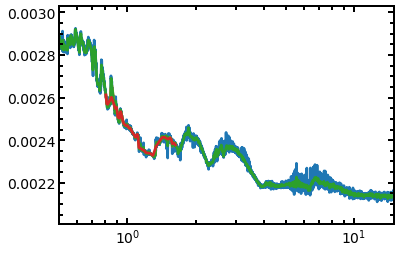

Regenerating spectra 1
1.0413982508377253e+26 24161274.378731973 0.0031367149976528957 11.90607399796173 91459.48511054127
Regenerating spectra 2
2.3449443907796697e+26 23400107.17056332 0.002504094483303808 28.581713611928908 85097.84824737279
Regenerating spectra 3
2.3031194660500225e+26 22940859.610230856 0.002434045527575056 29.20710417727501 23935.88543723813
Regenerating spectra 4
2.7457274509588914e+26 23276984.306029167 0.002420176567912114 33.821697914393894 31273.521086593733
Regenerating spectra 5
2.4707308374836605e+26 24050199.225091174 0.0023211794517031584 28.508836103424887 72816.91112391248
Regenerating spectra 6
2.3143473481304115e+26 23677969.866766024 0.0023623717446169474 27.55059746861726 52208.555112027876
Regenerating spectra 7
2.2171470444494824e+26 23072265.72753443 0.0026724125766836313 27.79747929240875 74291.1211036949
Regenerating spectra 8
1.0098676027075433e+26 24126049.950856306 0.007453159549404451 11.579329243613095 65402.05426269752
Regenerating spec

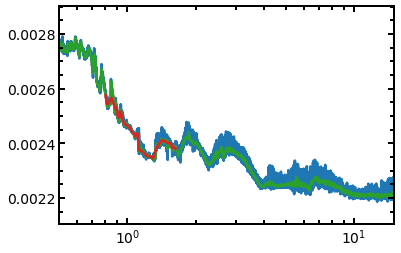

Regenerating spectra 51
1.6979420410619813e+26 23955251.707267262 0.0023080832668876143 19.747530472103154 49393.73068807786
Regenerating spectra 52
1.2866090712954315e+26 23219973.762531035 0.003822650496087008 15.926288106301858 71366.7232133123
Regenerating spectra 53
2.5974508387333484e+26 24552724.194171168 0.0032994025236376253 28.75672166730668 70982.63271809815
Regenerating spectra 54
2.2472560789465946e+26 23623863.48515124 0.014103824921406733 26.874607079247063 12747.974212075562
Regenerating spectra 55
2.5734360733960177e+26 22991288.70536533 0.0023717093538354016 32.4921285335355 46795.17856671371
Regenerating spectra 56
2.954015543957073e+26 23522319.26024086 0.003254201755954924 35.632303917048475 47532.732588259445
Regenerating spectra 57
1.748299927535366e+26 22916396.067721255 0.002481069750632719 22.218498598789125 94912.15160439923
Regenerating spectra 58
2.5985413885597486e+26 23951258.882715575 0.010353862718118882 30.231824423814558 9173.952775759484
Regenerating

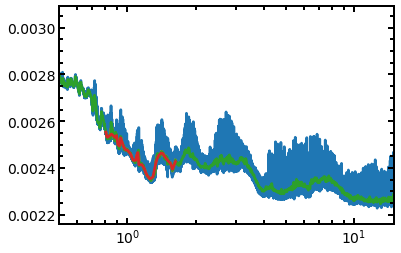

Regenerating spectra 101
1.0528734354665268e+26 23572626.886543825 0.004641455519739778 12.645954421098528 70581.34764247319
Regenerating spectra 102
2.375387123700787e+26 24338058.680500872 0.007753863034296277 26.76417977001674 20212.117034681294
Regenerating spectra 103
2.9350297371556678e+26 23432098.727879472 0.006452459917249398 35.67644208542685 24876.991075433256
Regenerating spectra 104
2.1728772295796397e+26 24425928.443564594 0.0023251496715345605 24.306612414646022 54103.70963798743
Regenerating spectra 105
2.5567739547486943e+26 23776461.653416064 0.0030823594785421506 30.184868798937234 56302.1577271555
Regenerating spectra 106
2.721566522584058e+26 23779973.74857531 0.002701916758102879 32.12089372749628 90858.56020654175
Regenerating spectra 107
1.600439985595793e+26 23936722.495552026 0.002750430157152474 18.6423832319224 32866.846703916046
Regenerating spectra 108
1.9077504308621048e+26 23456708.91983927 0.0022991833606842834 23.140823568389134 34241.437920101314
Rege

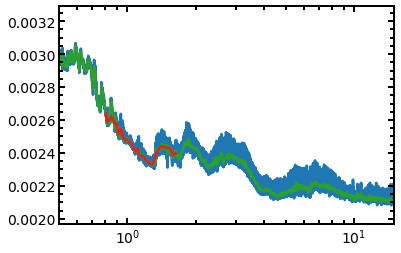

Regenerating spectra 151
1.652312398344241e+26 23746875.666066058 0.006345538376156045 19.555576027062283 24904.17210839521
Regenerating spectra 152
2.8910520437566e+26 24355226.894146565 0.0028195505515237417 32.52841920266752 86593.66711845579
Regenerating spectra 153
1.7045907279974262e+26 23619090.004854992 0.002470173269083709 20.393191978845355 42142.73975248894
Regenerating spectra 154
2.2050866655735726e+26 23766003.216271274 0.003528059812018225 26.05582135870302 39240.41667078879
Regenerating spectra 155
2.9390047649658673e+26 24034925.92844826 0.007622227627152183 33.955186656925825 19537.060399420916
Regenerating spectra 156
1.8986062117931517e+26 24118344.727140095 0.007059427341676808 21.783683024400005 15957.160852018173
Regenerating spectra 157
2.041017762536706e+26 24228803.754850492 0.002454282893063896 23.204608618965896 37008.519197406655
Regenerating spectra 158
1.3094021205491944e+26 24087556.512612425 0.009051587358948529 15.06187208089582 20773.477131304662
Rege

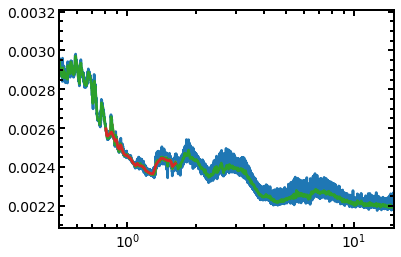

Regenerating spectra 201
1.7432587924119315e+26 22925355.892068766 0.002869033622600231 22.137119001755384 67585.17236695219
Regenerating spectra 202
2.6538785751610564e+26 23423190.76027296 0.002299915275308995 32.2834801794257 46912.766229620225
Regenerating spectra 203
2.624507084334104e+26 23568100.20611468 0.013883481436753487 31.534794517243444 9348.489560565244
Regenerating spectra 204
2.78804716395083e+26 22822455.395160075 0.0032169516680012745 35.72455192911724 63471.221984255215
Regenerating spectra 205
1.961489731226011e+26 24304070.232135773 0.0033690709172899645 22.16253446213132 107298.52881065872
Regenerating spectra 206
2.7829940709793258e+26 25382285.698650256 0.016561722351821243 28.829840049979413 13940.537987840255
Regenerating spectra 207
1.649022421522982e+26 24188116.940645054 0.0023512264046829223 18.81108516438397 159804.23830808947
Regenerating spectra 208
1.3641742910432322e+26 22863252.370849527 0.002915270167577947 17.417477102494868 61987.59281074938
Rege

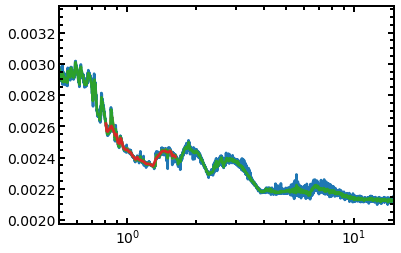

Regenerating spectra 251
2.234814652045274e+26 24335947.92601335 0.0023171820584078216 25.18467688619882 32010.641693546306
Regenerating spectra 252
1.4229537845838793e+26 23873540.142124213 0.012319348444922908 16.662821996604777 19323.74713856275
Regenerating spectra 253
2.789760429329062e+26 24340833.60293117 0.002791767837026341 31.425878203097763 73302.69430370221
Regenerating spectra 254
1.584472423618173e+26 23586299.66367816 0.002341419467444554 19.008877383107524 86426.88264758496
Regenerating spectra 255
2.2184255857740025e+26 22895199.64119692 0.002298391554685996 28.245378827395683 54108.96648000812
Regenerating spectra 256
2.1583494790718297e+26 23105710.599072255 0.003380252354351867 26.982023486871395 58301.08842728759
Regenerating spectra 257
1.819169374856272e+26 24400774.482491337 0.002520512598455878 20.391882597243047 61814.24389054159
Regenerating spectra 258
1.8803944272162224e+26 23132681.119632006 0.002377540718564631 23.45246092912033 80275.3689757321
Regenerat

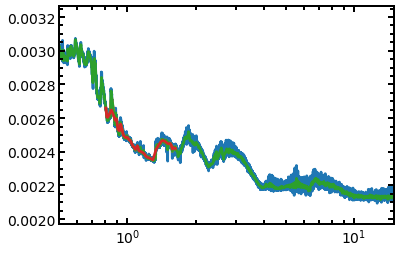

Regenerating spectra 301
1.9367892325836923e+26 23359888.262860697 0.014153561490600017 23.688210187753583 14541.063998570002
Regenerating spectra 302
1.4840493920270956e+26 23382806.399559923 0.0035665461238494245 18.11534025466245 63755.37651440099
Regenerating spectra 303
9.762172440810642e+25 23601023.48228471 0.008362356644201804 11.697046299474357 41394.48180796994
Regenerating spectra 304
2.032567147324409e+26 23630084.072075203 0.0024466333375258967 24.294377541223735 61659.80356842821
Regenerating spectra 305
2.5884367765788652e+26 23902890.892583817 0.004182510229711708 30.236262812755765 52110.94679608308
Regenerating spectra 306
2.819111360013056e+26 23475547.793374605 0.017231504113671737 34.14068019192023 11711.569738797803
Regenerating spectra 307
1.906959894436002e+26 23190705.638487924 0.003689674862861167 23.664920003873984 35080.78709219327
Regenerating spectra 308
8.995838000291532e+25 24245748.262011155 0.0023117781308156786 10.213200332083666 90118.68933371578
Reg

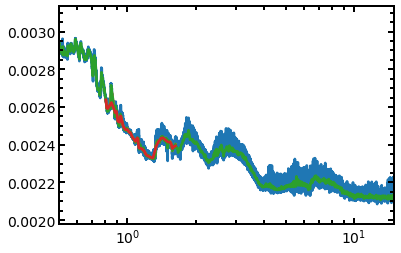

Regenerating spectra 351
1.869051245555664e+26 23935373.750711948 0.002493825441496131 21.773697767548256 57825.12615358255
Regenerating spectra 352
2.1612651778820932e+26 24857163.97687549 0.015125341836706873 23.34513070314792 17762.701269613597
Regenerating spectra 353
2.183626951168597e+26 23874146.247026186 0.007971511422619782 25.56902419731388 34254.24638578781
Regenerating spectra 354
2.0144712088737405e+26 23840223.908866066 0.0023088335593663676 23.6554826133947 70978.40056809479
Regenerating spectra 355
2.4793517033887393e+26 24098759.05459574 0.002404817519921756 28.49313174456675 78435.0645289858
Regenerating spectra 356
1.2578891595603979e+26 24051765.53087847 0.0022980268580805128 14.512420697524828 56345.6833351413
Regenerating spectra 357
2.4754489549887462e+26 24152866.549489677 0.002350614547996865 28.32096321475067 107199.47768588054
Regenerating spectra 358
1.2043299332934966e+26 23952267.948944397 0.01065410345740857 14.010176484675009 42649.96223347495
Regenerati

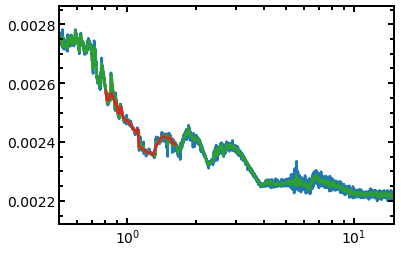

Regenerating spectra 401
2.44488957183044e+26 24432487.78119629 0.002338372201169697 27.33476066852446 44695.41745638259
Regenerating spectra 402
1.9345575724086945e+26 23925838.068023127 0.004310645174670581 22.554787970421643 51546.11236050671
Regenerating spectra 403
2.2007232524350722e+26 24513264.49178897 0.010033152234466235 24.443001696252825 25938.86889092669
Regenerating spectra 404
1.8979334382916424e+26 24192221.33430083 0.0028395034019865154 21.643171016100826 40536.788448217245
Regenerating spectra 405
1.511358615592415e+26 25657164.399962556 0.0023059350427407864 15.322923036942528 152067.7623200813
Regenerating spectra 406
2.2817264985159498e+26 25499211.376602132 0.0047269660114248446 23.42078762612281 48975.41063688815
Regenerating spectra 407
2.8105923280019824e+26 23929531.58676964 0.0023138114110127115 32.758263315462244 94439.41540973316
Regenerating spectra 408
2.1259962391420522e+26 24248369.564639788 0.00415504682558744 24.131749874564015 40836.626425300485
Rege

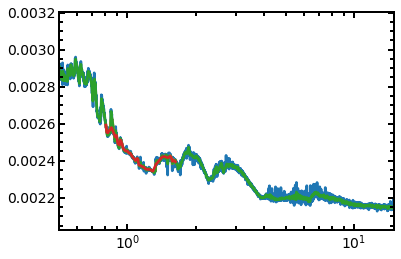

Regenerating spectra 451
2.2159395572214856e+26 24730970.057399586 0.0038238289723736547 24.18059677842344 25623.46488021555
Regenerating spectra 452
2.9223640097617586e+26 22036731.38706194 0.0023109561364326766 40.16348252752132 86126.97412216643
Regenerating spectra 453
2.6458174241258703e+26 23872986.61409615 0.0023004983343985273 30.98402049353811 50853.585085838306
Regenerating spectra 454
2.366353668783626e+26 24973238.365748055 0.0023022239209314083 25.323360452906144 56480.85422748866
Regenerating spectra 455
1.7313886413086337e+26 23241633.68721945 0.002312265485547651 21.39206296389088 66752.87154642135
Regenerating spectra 456
2.5522396654774765e+26 23774298.275284685 0.002301173506905525 30.13682163972037 65767.18946818536
Regenerating spectra 457
2.806985852278723e+26 23673667.473427758 0.011180461871051806 33.42724200833657 11895.537825382946
Regenerating spectra 458
1.8610932139080036e+26 23739507.04549808 0.004048750998276874 22.04023093109577 24170.80989927872
Regener

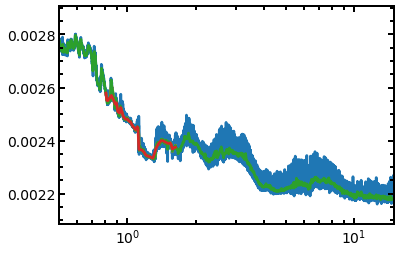

Regenerating spectra 501
2.1893732949522233e+26 23243184.556762576 0.0023024005990191763 27.04705369903732 96204.37337592024
Regenerating spectra 502
2.9821028612402493e+26 23775925.802845083 0.011717808317954544 35.20782151789934 6161.603407626301
Regenerating spectra 503
2.3850697950430314e+26 24309985.849565074 0.0023748246799516035 26.935378857247155 79613.89875527206
Regenerating spectra 504
1.879656815468387e+26 23502305.59213586 0.002313982385322982 22.711668153205487 95297.18105421533
Regenerating spectra 505
2.3483832112878243e+26 22940831.69875111 0.002300382935055275 29.781190690832563 85399.14561861777
Regenerating spectra 506
2.6960150232537736e+26 22920609.740476094 0.0023450305743292275 34.25006363118842 61285.36746748725
Regenerating spectra 507
2.3332465979050304e+26 23691623.954845957 0.002377355447641404 27.743572765996365 36567.23115087668
Regenerating spectra 508
1.4772910088954208e+26 22826018.647420615 0.0028194758144014826 18.923311014314415 90469.25956253042
Re

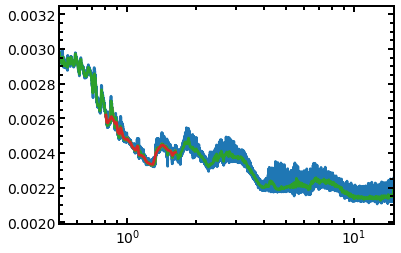

Regenerating spectra 551
2.439776019275497e+26 24203463.0284371 0.016423433768996687 27.796258886696965 13689.693066274725
Regenerating spectra 552
2.8387755573719124e+26 25217171.29586914 0.004106940507609999 29.79406275614262 28574.232459138002
Regenerating spectra 553
1.8940420009273323e+26 24544655.47342918 0.00758940664350511 20.98297835629225 14116.397445549814
Regenerating spectra 554
2.4807550619933738e+26 23591320.315274976 0.002386138786766694 29.748892312645243 66350.47746212484
Regenerating spectra 555
2.8627781120540623e+26 23656952.471884176 0.0023140376555567544 34.13984157517392 49848.192775951946
Regenerating spectra 556
2.302058592174442e+26 23212337.91089359 0.0023079295931514384 28.514779195301294 81540.1431507838
Regenerating spectra 557
2.8983070612079524e+26 23640087.379813395 0.0030147979225169067 34.61287293402758 56100.66452797216
Regenerating spectra 558
1.7499553299865272e+26 23110110.150519736 0.00384103944528477 21.86826560256034 53773.89245280463
Regenera

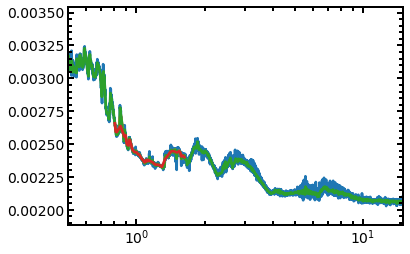

Regenerating spectra 601
2.0482785704914732e+26 24383022.86893019 0.002859262824803207 22.993513458081434 42849.28952158547
Regenerating spectra 602
2.3417252605806198e+26 23921754.91683156 0.002302673026050086 27.31123100305069 65738.7040931889
Regenerating spectra 603
2.706275232825003e+26 24890085.015443698 0.007477639058998222 29.154836556716464 25440.08768244747
Regenerating spectra 604
2.181686189857776e+26 24097840.524891652 0.002399978766693923 25.074220385215646 75871.96272476391
Regenerating spectra 605
2.020371498418994e+26 23611442.02555119 0.00295649141211912 24.186755704423767 95493.37589785595
Regenerating spectra 606
2.2731113688339416e+26 23818578.600845348 0.005270711593082396 26.741172178444362 19254.060329765452
Regenerating spectra 607
2.039479684571858e+26 23508867.66338579 0.0023230130106206993 24.62903348755695 107654.57842901324
Regenerating spectra 608
1.4561280003327827e+26 24972944.56433163 0.013282429762987137 15.58301379056707 9618.027274714856
Regeneratin

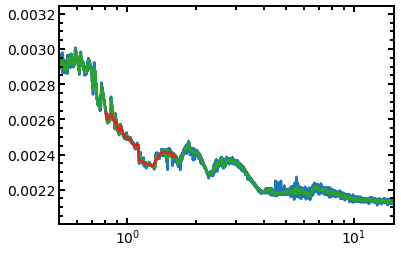

Regenerating spectra 651
2.1270285011092858e+26 24459852.79251678 0.013565680930378656 23.727776306975024 8288.375413800812
Regenerating spectra 652
2.0801309984465957e+26 23548792.424439453 0.0022991566887082056 25.034839474013072 38257.261896076256
Regenerating spectra 653
1.8406638576244834e+26 23104536.58144389 0.002641286048875225 23.012900976213103 45502.486633677734
Regenerating spectra 654
2.9631067350893414e+26 23253203.146779254 0.0023030674471264893 36.57405656505118 43144.44179155662
Regenerating spectra 655
1.92120489775453e+26 24323059.84358398 0.00715538442308123 21.673481356871342 45951.860394758376
Regenerating spectra 656
2.032848666806157e+26 23859274.305938125 0.002322205120375377 23.83318021567599 35031.033457310754
Regenerating spectra 657
2.9197014363889557e+26 23448032.400881767 0.0034719855782064774 35.44190364357381 31098.84834875761
Regenerating spectra 658
1.9827343057884855e+26 23701166.441829275 0.0028782605925291244 23.556810523519385 65126.0284353789
Reg

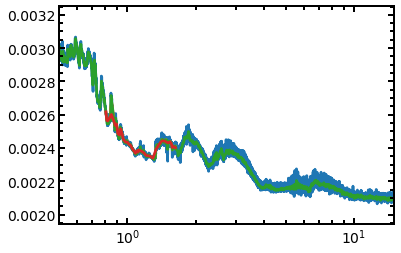

Regenerating spectra 701
2.5974807777535127e+26 24166684.802480116 0.013512489591809127 29.683123217144356 10343.945854491496
Regenerating spectra 702
1.7351393489592854e+26 24042158.31949605 0.0023215239142151396 20.034516292387057 41720.19788859857
Regenerating spectra 703
1.773199838384914e+26 24388319.14022474 0.002919904066836319 19.896897020881855 31433.543081707616
Regenerating spectra 704
2.5015978010160866e+26 23905428.80241034 0.00232207652497168 29.215667827526946 64407.62085731486
Regenerating spectra 705
2.519726272138527e+26 22682673.99517951 0.0023273016806049807 32.68558560872748 86325.90363504515
Regenerating spectra 706
2.4971280231529493e+26 24186970.664198726 0.002444602988624803 28.488478862106664 44658.115423736184
Regenerating spectra 707
2.566824828514185e+26 24787655.53170909 0.002444647774212149 27.88153854717441 59827.49688733181
Regenerating spectra 708
1.1526710029684318e+26 23205815.10238573 0.01018109852574199 14.285752474650526 38249.26712139099
Regenera

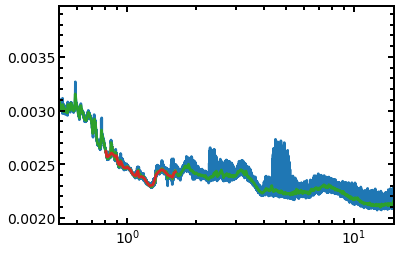

Regenerating spectra 751
1.5867035680532948e+26 24733463.075867053 0.00236371935873923 17.310808379502433 169858.3991752567
Regenerating spectra 752
1.4816575545534659e+26 23879029.17745147 0.0027185639048755176 17.342268881042713 63823.87817310715
Regenerating spectra 753
1.8259608048846244e+26 22974307.07278954 0.0023062728661706684 23.08862212568138 90775.17673683843
Regenerating spectra 754
1.1780470693697113e+26 22828639.267545618 0.002310212223722982 15.086691168695326 63757.39548753342
Regenerating spectra 755
2.0652421083525077e+26 24095148.901364073 0.0023001381417470414 23.7412264518755 50984.37169343945
Regenerating spectra 756
1.9342198709131185e+26 23781812.23988524 0.011059284218313644 22.824819761013604 25504.941221374214
Regenerating spectra 757
1.9159602726319865e+26 24172509.749187805 0.0037341518431527995 21.88438869099816 80964.7868440581
Regenerating spectra 758
2.1418683393560913e+26 24439139.27649959 0.003201650545987333 23.933839070494486 58096.62306907954
Regen

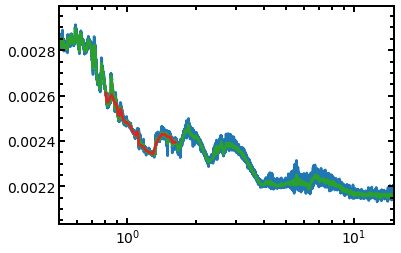

Regenerating spectra 801
2.9316688361735536e+26 24544836.78338305 0.002575246969132888 32.47775651203256 69498.77721068171
Regenerating spectra 802
2.6446831273406847e+26 23863777.695242293 0.004799920869372613 30.99464476958729 38886.60650627432
Regenerating spectra 803
2.2094618029501608e+26 24647632.202715024 0.0024406063094378604 24.273225836442098 82289.49178656365
Regenerating spectra 804
2.05539598068702e+26 24459492.280042186 0.003477842004598501 22.92936540085546 89714.94418558653
Regenerating spectra 805
1.667607378229162e+26 23193833.5665481 0.0023557546480859224 20.68903065847886 67903.61296023625
Regenerating spectra 806
2.769208665609534e+26 24026342.084907487 0.013102053765458649 32.01634694934934 13943.71493683617
Regenerating spectra 807
1.7481518326094576e+26 24073635.178099304 0.0167514697366887 20.132013288138978 22573.319096929063
Regenerating spectra 808
2.8378963946875164e+26 24588866.159666333 0.009854846759819548 31.326432405628893 18732.53085640979
Regeneratin

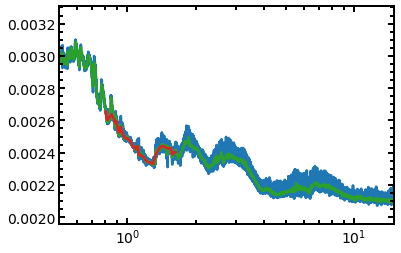

Regenerating spectra 851
7.522092854504248e+25 24008718.32597351 0.0042089330527848605 8.709478379172072 98237.75928764573
Regenerating spectra 852
2.160258341625084e+26 24466197.698324114 0.004326947768516135 24.085969798913318 45769.21766619319
Regenerating spectra 853
1.6068245385452333e+26 23776990.20829257 0.007788906774004639 18.9690729031291 23453.31636894164
Regenerating spectra 854
1.7279085241767286e+26 24137366.20529977 0.016835944927020514 19.793946689453776 17107.71674613581
Regenerating spectra 855
2.1236919030169332e+26 22907619.686715152 0.0023038838772803556 27.009900894491047 104294.34043189221
Regenerating spectra 856
2.4251966092302165e+26 24056441.452068426 0.0024545751361657324 27.96891318647089 77360.10609490178
Regenerating spectra 857
2.2022249596217284e+26 24010377.474337492 0.0023480067767513227 25.495005680694092 59915.35579282814
Regenerating spectra 858
2.5249028551186396e+26 22904133.676898435 0.0023719577174943956 32.1224263524565 31204.7163251652
Regene

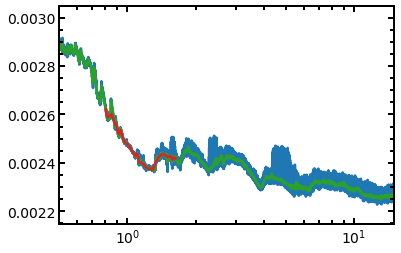

Regenerating spectra 901
7.197211327849372e+25 23404249.260993514 0.012760896054622663 8.769326363931256 19485.614574975694
Regenerating spectra 902
2.621362640733717e+26 24068952.137242027 0.00426213238588364 30.199805584561286 13229.235070423376
Regenerating spectra 903
2.4998123155079803e+26 23330983.839009795 0.002404805054848807 30.650157159376622 74320.66624191511
Regenerating spectra 904
2.6700630437293534e+26 23122096.82582659 0.0025767018671897825 33.33177893791913 61728.771581157176
Regenerating spectra 905
2.9115450009968406e+26 23911815.83178936 0.003489018247453639 33.985197713462746 36705.85117691836
Regenerating spectra 906
2.8623699737167425e+26 25476217.141982965 0.00231655260680255 29.43386488053801 80551.31364178148
Regenerating spectra 907
1.9097265633650638e+26 22804508.20280247 0.002328539391184384 24.508750771021752 145078.6813201108
Regenerating spectra 908
1.4106253290884546e+26 23459804.089432463 0.0026619946770902164 17.10623065996972 87381.35381925027
Regene

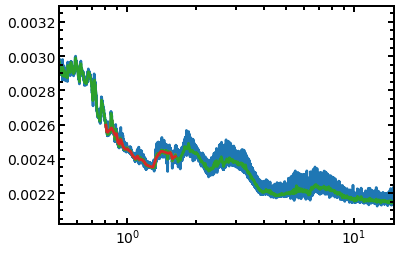

Regenerating spectra 951
1.2314266845990246e+26 24031637.210189417 0.003583433284752972 14.230928945303305 118512.4007989367
Regenerating spectra 952
2.7046959417590006e+26 23984663.168866813 0.007700167999686944 31.37925366161998 29268.832872447194
Regenerating spectra 953
1.0316883031839878e+26 24834575.15099249 0.007067474335080609 11.164170106329701 35277.504206951206
Regenerating spectra 954
2.200741222504735e+26 23853560.46290121 0.0023005911408611806 25.81392010279509 72067.40143027321
Regenerating spectra 955
2.767047866197548e+26 24555870.315175958 0.005353062665512094 30.626503481436888 46257.32382645786
Regenerating spectra 956
1.9320224161282565e+26 23062628.82599625 0.002383550742787699 24.24297704033913 58051.85463364754
Regenerating spectra 957
2.3039647029832207e+26 23826851.17196092 0.002571860983870911 27.085317148098913 87716.92844202895
Regenerating spectra 958
2.892193464506221e+26 23155377.279979654 0.0023028625530084543 36.001038224485434 57527.39220805109
Regene

In [40]:
spectout = {}
numsamp = min(1000,len(out['equal_samples'][:,0]))
sharr,pcldarr,scatfarr = np.zeros(numsamp),np.zeros(numsamp),np.zeros(numsamp)
#wavelengths_list,depths_list,info_dict_list,binwv_list,bintd_list = [],[],[],[],[]
depths_list,bintd_list,bintd_full_list = [],[],[]
for i in range(numsamp):
    print('Regenerating spectra',i)
    params = out['equal_samples'][i,:]
    datawv = out['transit_wavelengths']
    #vmrs=[]
    #for j in range(len(species)-1):
    #    vmrs.append(10.**params[j])
    #vmrs.append(1.-np.sum(vmrs))
    Rs = 0.8*R_sun
    Mp = params[2] * M_earth
    Rp = params[3] * R_earth
    T = params[4]
    logZ = params[8]
    CO_ratio = params[12]
    wavelengths, depths, info_dict = calculator.compute_depths(Rs, Mp, Rp, T, logZ=logZ, CO_ratio=CO_ratio, 
                                                               #gases=species,vmrs=vmrs, 
                                                               scattering_factor=10.**params[5],
                                                               scattering_slope=params[6],
                                                               cloudtop_pressure=10.**(params[9]+5),
                                                               T_star=params[0],T_spot=params[1],
                                                               spot_cov_frac=params[7],full_output=True)
    
    # compute scale heights 
    #print(info_dict['P_profile'],10.**(params[9]+5))
    if np.max(info_dict['P_profile']) > 1e5:
        #print(len(info_dict['P_profile']),len(info_dict['mu_profile']))
        mu = interpolate.interp1d(info_dict['P_profile'],
                                  info_dict['mu_profile'][:len(info_dict['P_profile'])])(1e5)/1e3
    else:
        mu = info_dict['mu_profile'][-1]/1e3
    #print(mu)
    gr = G*Mp/Rp**2
    sh = R.value*T/(mu*gr)
    print(Mp,Rp,mu,gr,sh)
    sharr[i] = sh
    pcldarr[i] = 10.**(params[9]+5)
    scatfarr[i] = 10.**params[5]
        
    depths[0:len(wavelengths[wavelengths<datawv[n102-1]])] += params[11] / 1e6
    
    binwv = np.linspace(np.min(datawv),np.max(datawv),num=100)    
    bintd = spectres(binwv, wavelengths, depths)
        
    binwv_full = np.logspace(np.log10(0.3e-6),np.log10(15e-6),num=1000)
    bintd_full = spectres(binwv_full,wavelengths,depths)
    
    #print(bintd_full)

    if i%50 == 0:
        plt.semilogx(wavelengths*1e6,depths)
        plt.semilogx(binwv*1e6,bintd)
        plt.semilogx(binwv_full*1e6,bintd_full)
        plt.semilogx(out['transit_wavelengths']*1e6,out['random_transit_depths'][i])
        plt.xlim([0.5,15.0])
        plt.show()        

    #wavelengths_list.append(wavelengths)
    depths_list.append(depths)
    #info_dict_list.append(info_dict)
    #binwv_list.append(binwv)
    bintd_list.append(bintd)
    bintd_full_list.append(bintd_full)

spectout['wavelengths'] = wavelengths
spectout['depths'] = depths_list
#spectout['info_dict'] = info_dict_list
spectout['binwv'] = binwv
spectout['bintd'] = bintd_list
spectout['binwv_full'] = binwv_full
spectout['bintd_full'] = bintd_full_list

f = open('aumicb_newDataDec28_newT_100PointRandomModelSpectra.pkl','wb')
pickle.dump(spectout,f)
f.close()

Regenerating spectra 0


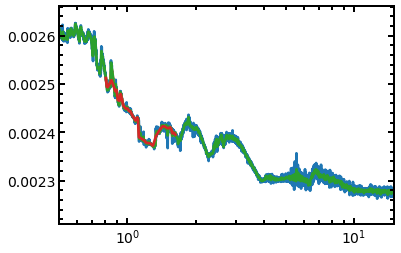

Regenerating spectra 1
Regenerating spectra 2
Regenerating spectra 3
Regenerating spectra 4
Regenerating spectra 5
Regenerating spectra 6
Regenerating spectra 7
Regenerating spectra 8
Regenerating spectra 9
Regenerating spectra 10
Regenerating spectra 11
Regenerating spectra 12
Regenerating spectra 13
Regenerating spectra 14
Regenerating spectra 15
Regenerating spectra 16
Regenerating spectra 17
Regenerating spectra 18
Regenerating spectra 19
Regenerating spectra 20
Regenerating spectra 21
Regenerating spectra 22
Regenerating spectra 23
Regenerating spectra 24
Regenerating spectra 25
Regenerating spectra 26
Regenerating spectra 27
Regenerating spectra 28
Regenerating spectra 29
Regenerating spectra 30
Regenerating spectra 31
Regenerating spectra 32
Regenerating spectra 33
Regenerating spectra 34
Regenerating spectra 35
Regenerating spectra 36
Regenerating spectra 37
Regenerating spectra 38
Regenerating spectra 39
Regenerating spectra 40
Regenerating spectra 41
Regenerating spectra 42
R

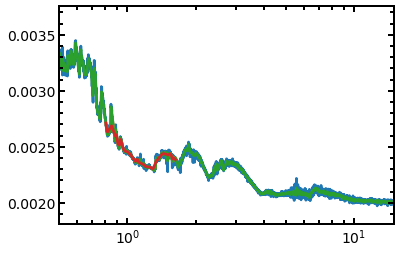

Regenerating spectra 51
Regenerating spectra 52
Regenerating spectra 53
Regenerating spectra 54
Regenerating spectra 55
Regenerating spectra 56
Regenerating spectra 57
Regenerating spectra 58
Regenerating spectra 59
Regenerating spectra 60
Regenerating spectra 61
Regenerating spectra 62
Regenerating spectra 63
Regenerating spectra 64
Regenerating spectra 65
Regenerating spectra 66
Regenerating spectra 67
Regenerating spectra 68
Regenerating spectra 69
Regenerating spectra 70
Regenerating spectra 71
Regenerating spectra 72
Regenerating spectra 73
Regenerating spectra 74
Regenerating spectra 75
Regenerating spectra 76
Regenerating spectra 77
Regenerating spectra 78
Regenerating spectra 79
Regenerating spectra 80
Regenerating spectra 81
Regenerating spectra 82
Regenerating spectra 83
Regenerating spectra 84
Regenerating spectra 85
Regenerating spectra 86
Regenerating spectra 87
Regenerating spectra 88
Regenerating spectra 89
Regenerating spectra 90
Regenerating spectra 91
Regenerating spe

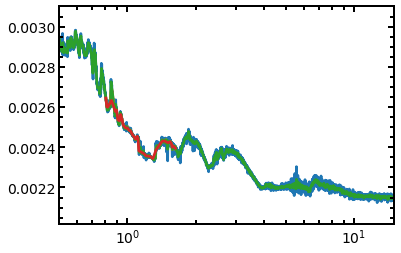

Regenerating spectra 101
Regenerating spectra 102
Regenerating spectra 103
Regenerating spectra 104
Regenerating spectra 105
Regenerating spectra 106
Regenerating spectra 107
Regenerating spectra 108
Regenerating spectra 109
Regenerating spectra 110
Regenerating spectra 111
Regenerating spectra 112
Regenerating spectra 113
Regenerating spectra 114
Regenerating spectra 115
Regenerating spectra 116
Regenerating spectra 117
Regenerating spectra 118
Regenerating spectra 119
Regenerating spectra 120
Regenerating spectra 121
Regenerating spectra 122
Regenerating spectra 123
Regenerating spectra 124
Regenerating spectra 125
Regenerating spectra 126
Regenerating spectra 127
Regenerating spectra 128
Regenerating spectra 129
Regenerating spectra 130
Regenerating spectra 131
Regenerating spectra 132
Regenerating spectra 133
Regenerating spectra 134
Regenerating spectra 135
Regenerating spectra 136
Regenerating spectra 137
Regenerating spectra 138
Regenerating spectra 139
Regenerating spectra 140


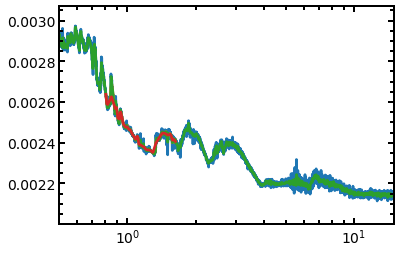

Regenerating spectra 151
Regenerating spectra 152
Regenerating spectra 153
Regenerating spectra 154
Regenerating spectra 155
Regenerating spectra 156
Regenerating spectra 157
Regenerating spectra 158
Regenerating spectra 159
Regenerating spectra 160
Regenerating spectra 161
Regenerating spectra 162
Regenerating spectra 163
Regenerating spectra 164
Regenerating spectra 165
Regenerating spectra 166
Regenerating spectra 167
Regenerating spectra 168
Regenerating spectra 169
Regenerating spectra 170
Regenerating spectra 171
Regenerating spectra 172
Regenerating spectra 173
Regenerating spectra 174
Regenerating spectra 175
Regenerating spectra 176
Regenerating spectra 177
Regenerating spectra 178
Regenerating spectra 179
Regenerating spectra 180
Regenerating spectra 181
Regenerating spectra 182
Regenerating spectra 183
Regenerating spectra 184
Regenerating spectra 185
Regenerating spectra 186
Regenerating spectra 187
Regenerating spectra 188
Regenerating spectra 189
Regenerating spectra 190


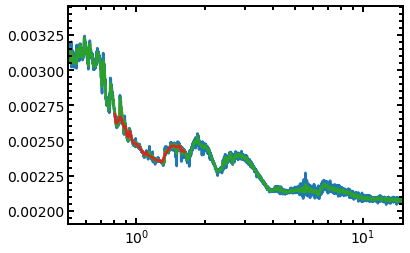

Regenerating spectra 201
Regenerating spectra 202
Regenerating spectra 203
Regenerating spectra 204
Regenerating spectra 205
Regenerating spectra 206
Regenerating spectra 207
Regenerating spectra 208
Regenerating spectra 209
Regenerating spectra 210
Regenerating spectra 211
Regenerating spectra 212
Regenerating spectra 213
Regenerating spectra 214
Regenerating spectra 215
Regenerating spectra 216
Regenerating spectra 217
Regenerating spectra 218
Regenerating spectra 219
Regenerating spectra 220
Regenerating spectra 221
Regenerating spectra 222
Regenerating spectra 223
Regenerating spectra 224
Regenerating spectra 225
Regenerating spectra 226
Regenerating spectra 227
Regenerating spectra 228
Regenerating spectra 229
Regenerating spectra 230
Regenerating spectra 231
Regenerating spectra 232
Regenerating spectra 233
Regenerating spectra 234
Regenerating spectra 235
Regenerating spectra 236
Regenerating spectra 237
Regenerating spectra 238
Regenerating spectra 239
Regenerating spectra 240


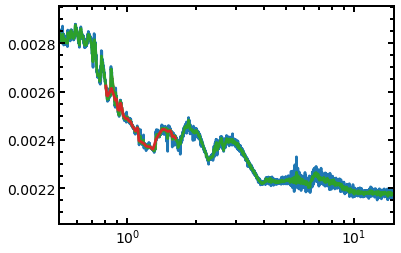

Regenerating spectra 251
Regenerating spectra 252
Regenerating spectra 253
Regenerating spectra 254
Regenerating spectra 255
Regenerating spectra 256
Regenerating spectra 257
Regenerating spectra 258
Regenerating spectra 259
Regenerating spectra 260
Regenerating spectra 261
Regenerating spectra 262
Regenerating spectra 263
Regenerating spectra 264
Regenerating spectra 265
Regenerating spectra 266
Regenerating spectra 267
Regenerating spectra 268
Regenerating spectra 269
Regenerating spectra 270
Regenerating spectra 271
Regenerating spectra 272
Regenerating spectra 273
Regenerating spectra 274
Regenerating spectra 275
Regenerating spectra 276
Regenerating spectra 277
Regenerating spectra 278
Regenerating spectra 279
Regenerating spectra 280
Regenerating spectra 281
Regenerating spectra 282
Regenerating spectra 283
Regenerating spectra 284
Regenerating spectra 285
Regenerating spectra 286
Regenerating spectra 287
Regenerating spectra 288
Regenerating spectra 289
Regenerating spectra 290


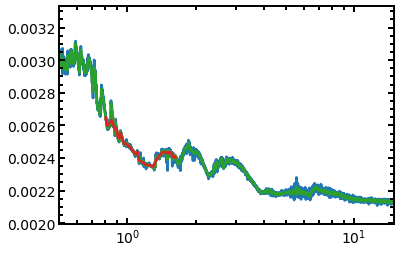

Regenerating spectra 301
Regenerating spectra 302
Regenerating spectra 303
Regenerating spectra 304
Regenerating spectra 305
Regenerating spectra 306
Regenerating spectra 307
Regenerating spectra 308
Regenerating spectra 309
Regenerating spectra 310
Regenerating spectra 311
Regenerating spectra 312
Regenerating spectra 313
Regenerating spectra 314
Regenerating spectra 315
Regenerating spectra 316
Regenerating spectra 317
Regenerating spectra 318
Regenerating spectra 319
Regenerating spectra 320
Regenerating spectra 321
Regenerating spectra 322
Regenerating spectra 323
Regenerating spectra 324
Regenerating spectra 325
Regenerating spectra 326
Regenerating spectra 327
Regenerating spectra 328
Regenerating spectra 329
Regenerating spectra 330
Regenerating spectra 331
Regenerating spectra 332
Regenerating spectra 333
Regenerating spectra 334
Regenerating spectra 335
Regenerating spectra 336
Regenerating spectra 337
Regenerating spectra 338
Regenerating spectra 339
Regenerating spectra 340


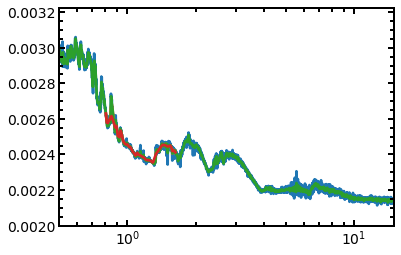

Regenerating spectra 351
Regenerating spectra 352
Regenerating spectra 353
Regenerating spectra 354
Regenerating spectra 355
Regenerating spectra 356
Regenerating spectra 357
Regenerating spectra 358
Regenerating spectra 359
Regenerating spectra 360
Regenerating spectra 361
Regenerating spectra 362
Regenerating spectra 363
Regenerating spectra 364
Regenerating spectra 365
Regenerating spectra 366
Regenerating spectra 367
Regenerating spectra 368
Regenerating spectra 369
Regenerating spectra 370
Regenerating spectra 371
Regenerating spectra 372
Regenerating spectra 373
Regenerating spectra 374
Regenerating spectra 375
Regenerating spectra 376
Regenerating spectra 377
Regenerating spectra 378
Regenerating spectra 379
Regenerating spectra 380
Regenerating spectra 381
Regenerating spectra 382
Regenerating spectra 383
Regenerating spectra 384
Regenerating spectra 385
Regenerating spectra 386
Regenerating spectra 387
Regenerating spectra 388
Regenerating spectra 389
Regenerating spectra 390


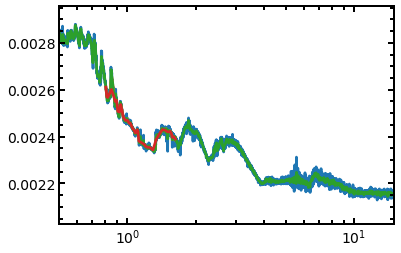

Regenerating spectra 401
Regenerating spectra 402
Regenerating spectra 403
Regenerating spectra 404
Regenerating spectra 405
Regenerating spectra 406
Regenerating spectra 407
Regenerating spectra 408
Regenerating spectra 409
Regenerating spectra 410
Regenerating spectra 411
Regenerating spectra 412
Regenerating spectra 413
Regenerating spectra 414
Regenerating spectra 415
Regenerating spectra 416
Regenerating spectra 417
Regenerating spectra 418
Regenerating spectra 419
Regenerating spectra 420
Regenerating spectra 421
Regenerating spectra 422
Regenerating spectra 423
Regenerating spectra 424
Regenerating spectra 425
Regenerating spectra 426
Regenerating spectra 427
Regenerating spectra 428
Regenerating spectra 429
Regenerating spectra 430
Regenerating spectra 431
Regenerating spectra 432
Regenerating spectra 433
Regenerating spectra 434
Regenerating spectra 435
Regenerating spectra 436
Regenerating spectra 437
Regenerating spectra 438
Regenerating spectra 439
Regenerating spectra 440


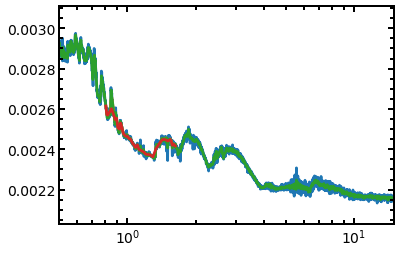

Regenerating spectra 451
Regenerating spectra 452
Regenerating spectra 453
Regenerating spectra 454
Regenerating spectra 455
Regenerating spectra 456
Regenerating spectra 457
Regenerating spectra 458
Regenerating spectra 459
Regenerating spectra 460
Regenerating spectra 461
Regenerating spectra 462
Regenerating spectra 463
Regenerating spectra 464
Regenerating spectra 465
Regenerating spectra 466
Regenerating spectra 467
Regenerating spectra 468
Regenerating spectra 469
Regenerating spectra 470
Regenerating spectra 471
Regenerating spectra 472
Regenerating spectra 473
Regenerating spectra 474
Regenerating spectra 475
Regenerating spectra 476
Regenerating spectra 477
Regenerating spectra 478
Regenerating spectra 479
Regenerating spectra 480
Regenerating spectra 481
Regenerating spectra 482
Regenerating spectra 483
Regenerating spectra 484
Regenerating spectra 485
Regenerating spectra 486
Regenerating spectra 487
Regenerating spectra 488
Regenerating spectra 489
Regenerating spectra 490


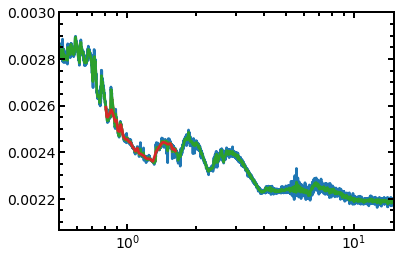

Regenerating spectra 501
Regenerating spectra 502
Regenerating spectra 503
Regenerating spectra 504
Regenerating spectra 505
Regenerating spectra 506
Regenerating spectra 507
Regenerating spectra 508
Regenerating spectra 509
Regenerating spectra 510
Regenerating spectra 511
Regenerating spectra 512
Regenerating spectra 513
Regenerating spectra 514
Regenerating spectra 515
Regenerating spectra 516
Regenerating spectra 517
Regenerating spectra 518
Regenerating spectra 519
Regenerating spectra 520
Regenerating spectra 521
Regenerating spectra 522
Regenerating spectra 523
Regenerating spectra 524
Regenerating spectra 525
Regenerating spectra 526
Regenerating spectra 527
Regenerating spectra 528
Regenerating spectra 529
Regenerating spectra 530
Regenerating spectra 531
Regenerating spectra 532
Regenerating spectra 533
Regenerating spectra 534
Regenerating spectra 535
Regenerating spectra 536
Regenerating spectra 537
Regenerating spectra 538
Regenerating spectra 539
Regenerating spectra 540


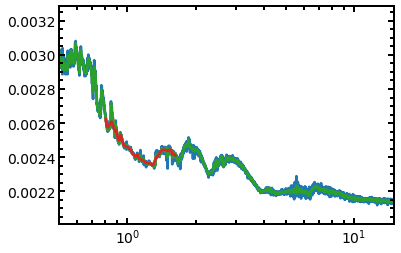

Regenerating spectra 551
Regenerating spectra 552
Regenerating spectra 553
Regenerating spectra 554
Regenerating spectra 555
Regenerating spectra 556
Regenerating spectra 557
Regenerating spectra 558
Regenerating spectra 559
Regenerating spectra 560
Regenerating spectra 561
Regenerating spectra 562
Regenerating spectra 563
Regenerating spectra 564
Regenerating spectra 565
Regenerating spectra 566
Regenerating spectra 567
Regenerating spectra 568
Regenerating spectra 569
Regenerating spectra 570
Regenerating spectra 571
Regenerating spectra 572
Regenerating spectra 573
Regenerating spectra 574
Regenerating spectra 575
Regenerating spectra 576
Regenerating spectra 577
Regenerating spectra 578
Regenerating spectra 579
Regenerating spectra 580
Regenerating spectra 581
Regenerating spectra 582
Regenerating spectra 583
Regenerating spectra 584
Regenerating spectra 585
Regenerating spectra 586
Regenerating spectra 587
Regenerating spectra 588
Regenerating spectra 589
Regenerating spectra 590


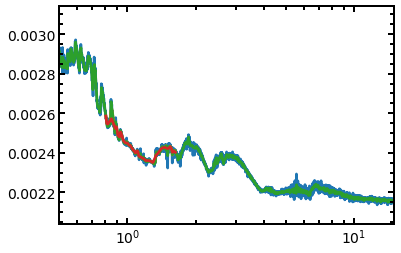

Regenerating spectra 601
Regenerating spectra 602
Regenerating spectra 603
Regenerating spectra 604
Regenerating spectra 605
Regenerating spectra 606
Regenerating spectra 607
Regenerating spectra 608
Regenerating spectra 609
Regenerating spectra 610
Regenerating spectra 611
Regenerating spectra 612
Regenerating spectra 613
Regenerating spectra 614
Regenerating spectra 615
Regenerating spectra 616
Regenerating spectra 617
Regenerating spectra 618
Regenerating spectra 619
Regenerating spectra 620
Regenerating spectra 621
Regenerating spectra 622
Regenerating spectra 623
Regenerating spectra 624
Regenerating spectra 625
Regenerating spectra 626
Regenerating spectra 627
Regenerating spectra 628
Regenerating spectra 629
Regenerating spectra 630
Regenerating spectra 631
Regenerating spectra 632
Regenerating spectra 633
Regenerating spectra 634
Regenerating spectra 635
Regenerating spectra 636
Regenerating spectra 637
Regenerating spectra 638
Regenerating spectra 639
Regenerating spectra 640


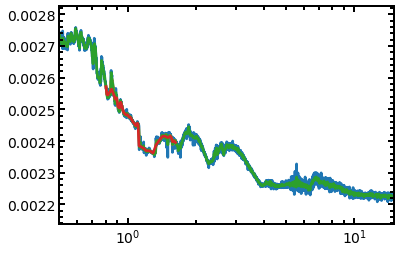

Regenerating spectra 651
Regenerating spectra 652
Regenerating spectra 653
Regenerating spectra 654
Regenerating spectra 655
Regenerating spectra 656
Regenerating spectra 657
Regenerating spectra 658
Regenerating spectra 659
Regenerating spectra 660
Regenerating spectra 661
Regenerating spectra 662
Regenerating spectra 663
Regenerating spectra 664
Regenerating spectra 665
Regenerating spectra 666
Regenerating spectra 667
Regenerating spectra 668
Regenerating spectra 669
Regenerating spectra 670
Regenerating spectra 671
Regenerating spectra 672
Regenerating spectra 673
Regenerating spectra 674
Regenerating spectra 675
Regenerating spectra 676
Regenerating spectra 677
Regenerating spectra 678
Regenerating spectra 679
Regenerating spectra 680
Regenerating spectra 681
Regenerating spectra 682
Regenerating spectra 683
Regenerating spectra 684
Regenerating spectra 685
Regenerating spectra 686
Regenerating spectra 687
Regenerating spectra 688
Regenerating spectra 689
Regenerating spectra 690


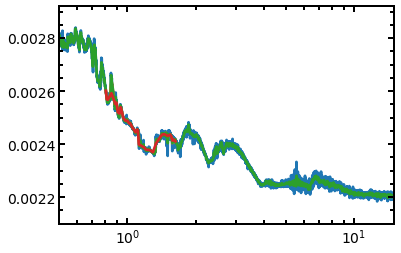

Regenerating spectra 701
Regenerating spectra 702
Regenerating spectra 703
Regenerating spectra 704
Regenerating spectra 705
Regenerating spectra 706
Regenerating spectra 707
Regenerating spectra 708
Regenerating spectra 709
Regenerating spectra 710
Regenerating spectra 711
Regenerating spectra 712
Regenerating spectra 713
Regenerating spectra 714
Regenerating spectra 715
Regenerating spectra 716
Regenerating spectra 717
Regenerating spectra 718
Regenerating spectra 719
Regenerating spectra 720
Regenerating spectra 721
Regenerating spectra 722
Regenerating spectra 723
Regenerating spectra 724
Regenerating spectra 725
Regenerating spectra 726
Regenerating spectra 727
Regenerating spectra 728
Regenerating spectra 729
Regenerating spectra 730
Regenerating spectra 731
Regenerating spectra 732
Regenerating spectra 733
Regenerating spectra 734
Regenerating spectra 735
Regenerating spectra 736
Regenerating spectra 737
Regenerating spectra 738
Regenerating spectra 739
Regenerating spectra 740


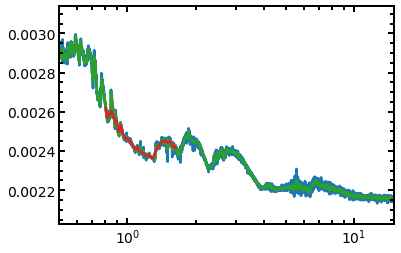

Regenerating spectra 751
Regenerating spectra 752
Regenerating spectra 753
Regenerating spectra 754
Regenerating spectra 755
Regenerating spectra 756
Regenerating spectra 757
Regenerating spectra 758
Regenerating spectra 759
Regenerating spectra 760
Regenerating spectra 761
Regenerating spectra 762
Regenerating spectra 763
Regenerating spectra 764
Regenerating spectra 765
Regenerating spectra 766
Regenerating spectra 767
Regenerating spectra 768
Regenerating spectra 769
Regenerating spectra 770
Regenerating spectra 771
Regenerating spectra 772
Regenerating spectra 773
Regenerating spectra 774
Regenerating spectra 775
Regenerating spectra 776
Regenerating spectra 777
Regenerating spectra 778
Regenerating spectra 779
Regenerating spectra 780
Regenerating spectra 781
Regenerating spectra 782
Regenerating spectra 783
Regenerating spectra 784
Regenerating spectra 785
Regenerating spectra 786
Regenerating spectra 787
Regenerating spectra 788
Regenerating spectra 789
Regenerating spectra 790


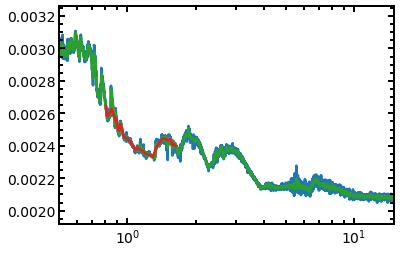

Regenerating spectra 801
Regenerating spectra 802
Regenerating spectra 803
Regenerating spectra 804
Regenerating spectra 805
Regenerating spectra 806
Regenerating spectra 807
Regenerating spectra 808
Regenerating spectra 809
Regenerating spectra 810
Regenerating spectra 811
Regenerating spectra 812
Regenerating spectra 813
Regenerating spectra 814
Regenerating spectra 815
Regenerating spectra 816
Regenerating spectra 817
Regenerating spectra 818
Regenerating spectra 819
Regenerating spectra 820
Regenerating spectra 821
Regenerating spectra 822
Regenerating spectra 823
Regenerating spectra 824
Regenerating spectra 825
Regenerating spectra 826
Regenerating spectra 827
Regenerating spectra 828
Regenerating spectra 829
Regenerating spectra 830
Regenerating spectra 831
Regenerating spectra 832
Regenerating spectra 833
Regenerating spectra 834
Regenerating spectra 835
Regenerating spectra 836
Regenerating spectra 837
Regenerating spectra 838
Regenerating spectra 839
Regenerating spectra 840


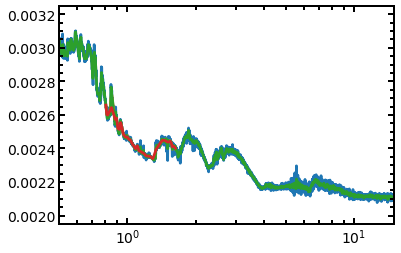

Regenerating spectra 851
Regenerating spectra 852
Regenerating spectra 853
Regenerating spectra 854
Regenerating spectra 855
Regenerating spectra 856
Regenerating spectra 857
Regenerating spectra 858
Regenerating spectra 859
Regenerating spectra 860
Regenerating spectra 861
Regenerating spectra 862
Regenerating spectra 863
Regenerating spectra 864
Regenerating spectra 865
Regenerating spectra 866
Regenerating spectra 867
Regenerating spectra 868
Regenerating spectra 869
Regenerating spectra 870
Regenerating spectra 871
Regenerating spectra 872
Regenerating spectra 873
Regenerating spectra 874
Regenerating spectra 875
Regenerating spectra 876
Regenerating spectra 877
Regenerating spectra 878
Regenerating spectra 879
Regenerating spectra 880
Regenerating spectra 881
Regenerating spectra 882
Regenerating spectra 883
Regenerating spectra 884
Regenerating spectra 885
Regenerating spectra 886
Regenerating spectra 887
Regenerating spectra 888
Regenerating spectra 889
Regenerating spectra 890


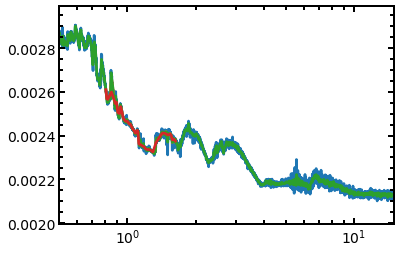

Regenerating spectra 901
Regenerating spectra 902
Regenerating spectra 903
Regenerating spectra 904
Regenerating spectra 905
Regenerating spectra 906
Regenerating spectra 907
Regenerating spectra 908
Regenerating spectra 909
Regenerating spectra 910
Regenerating spectra 911
Regenerating spectra 912
Regenerating spectra 913
Regenerating spectra 914
Regenerating spectra 915
Regenerating spectra 916
Regenerating spectra 917
Regenerating spectra 918
Regenerating spectra 919
Regenerating spectra 920
Regenerating spectra 921
Regenerating spectra 922
Regenerating spectra 923
Regenerating spectra 924
Regenerating spectra 925
Regenerating spectra 926
Regenerating spectra 927
Regenerating spectra 928
Regenerating spectra 929
Regenerating spectra 930
Regenerating spectra 931
Regenerating spectra 932
Regenerating spectra 933
Regenerating spectra 934
Regenerating spectra 935
Regenerating spectra 936
Regenerating spectra 937
Regenerating spectra 938
Regenerating spectra 939
Regenerating spectra 940


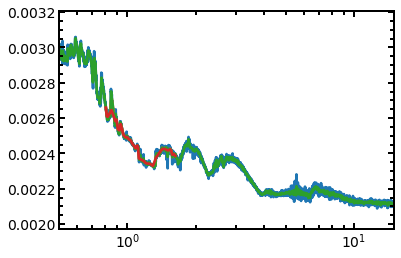

Regenerating spectra 951
Regenerating spectra 952
Regenerating spectra 953
Regenerating spectra 954
Regenerating spectra 955
Regenerating spectra 956
Regenerating spectra 957
Regenerating spectra 958
Regenerating spectra 959
Regenerating spectra 960
Regenerating spectra 961
Regenerating spectra 962
Regenerating spectra 963
Regenerating spectra 964
Regenerating spectra 965
Regenerating spectra 966
Regenerating spectra 967
Regenerating spectra 968
Regenerating spectra 969
Regenerating spectra 970
Regenerating spectra 971
Regenerating spectra 972
Regenerating spectra 973
Regenerating spectra 974
Regenerating spectra 975
Regenerating spectra 976
Regenerating spectra 977
Regenerating spectra 978
Regenerating spectra 979
Regenerating spectra 980
Regenerating spectra 981
Regenerating spectra 982
Regenerating spectra 983
Regenerating spectra 984
Regenerating spectra 985
Regenerating spectra 986
Regenerating spectra 987
Regenerating spectra 988
Regenerating spectra 989
Regenerating spectra 990


In [9]:
spectouttls = {}
numsamp = min(1000,len(outtls['equal_samples'][:,0]))
#wavelengths_list,depths_list,info_dict_list,binwv_list,bintd_list = [],[],[],[],[]
depths_list,bintd_list,bintd_full_list = [],[],[]
for i in range(numsamp):
    print('Regenerating spectra',i)
    params = outtls['equal_samples'][i,:]
    datawv = outtls['transit_wavelengths']
    #vmrs=[]
    #for j in range(len(species)-1):
    #    vmrs.append(10.**params[j])
    #vmrs.append(1.-np.sum(vmrs))
    Rs = 0.8*R_sun
    Mp = 50.*M_earth
    Rp = params[2]
    T = 200.0
    logZ = -1.
    CO_ratio = 0.59
    wavelengths, depths, info_dict = calculator.compute_depths(Rs, Mp, Rp, T, logZ=logZ, CO_ratio=CO_ratio, 
                                                               #gases=species,vmrs=vmrs, 
                                                               scattering_factor=1.,
                                                               scattering_slope=4.,
                                                               cloudtop_pressure=10.**-3.999,
                                                               T_star=params[0],T_spot=params[1],
                                                               spot_cov_frac=params[3],full_output=True)
        
    depths[0:len(wavelengths[wavelengths<datawv[n102-1]])] += params[5]
    
    binwv = np.linspace(np.min(datawv),np.max(datawv),num=100)    
    bintd = spectres(binwv,wavelengths,depths)
    
    binwv_full = np.logspace(np.log10(0.3e-6),np.log10(15e-6),num=1000)
    bintd_full = spectres(binwv_full,wavelengths,depths)

    if i%50 == 0:
        plt.semilogx(wavelengths*1e6,depths)
        plt.semilogx(binwv*1e6,bintd)
        plt.semilogx(binwv_full*1e6,bintd_full)
        plt.semilogx(outtls['transit_wavelengths']*1e6,outtls['random_transit_depths'][i])
        plt.xlim([0.5,15.0])
        plt.show()        

    #wavelengths_list.append(wavelengths)
    depths_list.append(depths)
    #info_dict_list.append(info_dict)
    #binwv_list.append(binwv)
    bintd_list.append(bintd)
    bintd_full_list.append(bintd_full)

spectouttls['wavelengths'] = wavelengths
spectouttls['depths'] = depths_list
#spectouttls['info_dict'] = info_dict_list
spectouttls['binwv'] = binwv
spectouttls['bintd'] = bintd_list
spectouttls['binwv_full'] = binwv_full
spectouttls['bintd_full'] = bintd_full_list

f = open('aumicb_newDataDec28_TLSonly_newT_100PointRandomModelSpectra.pkl','wb')
pickle.dump(spectouttls,f)
f.close()

Regenerating spectra 0
2.521123663382502e+26 23702784.39070243 0.0025110610494055202 29.94931024867187 86416.10011766515


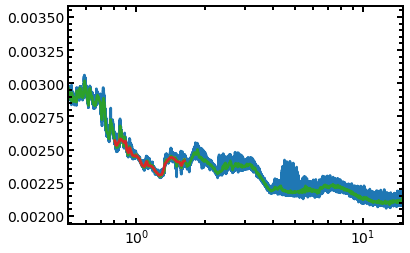

Regenerating spectra 1
2.284469194899907e+26 24072336.972389635 0.0023087458987348882 26.31117274272127 127882.83478529645
Regenerating spectra 2
8.878892258392787e+25 24115630.115102842 0.007834010701598493 10.189502167779322 52051.32460173717
Regenerating spectra 3
2.2337033128813353e+26 23801310.044661075 0.002314018330697199 26.31571492586674 45436.31438688493
Regenerating spectra 4
1.563309067476222e+26 23367759.338816658 0.003272135596313059 19.107422751458778 129837.55914107444
Regenerating spectra 5
2.2473546227898435e+26 24135454.10757766 0.0036948794172070557 25.748507875912665 71024.59810926525
Regenerating spectra 6
2.124945717140309e+26 23759510.11299564 0.0023334665206050354 25.122582703506982 59989.70524220508
Regenerating spectra 7
2.623995709169695e+26 24292422.454100907 0.0025599569252696343 29.676513591500917 36644.51016786428
Regenerating spectra 8
2.2827634637015128e+26 24070024.493885595 0.004197834867128935 26.296579186228158 35559.51346485066
Regenerating spectr

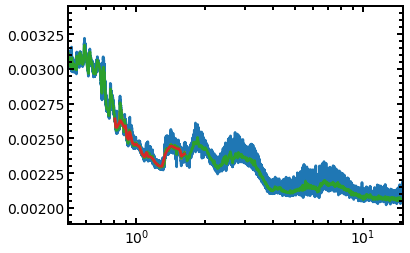

Regenerating spectra 51
2.0134154898491847e+26 25551303.751801275 0.0024338252952882215 20.582526528695347 132305.35234700888
Regenerating spectra 52
2.0621295798382144e+26 23525188.25627819 0.0023001136672236785 24.868016398621343 43852.16564603428
Regenerating spectra 53
1.910189525175099e+26 23533547.83827982 0.0023630446200062936 23.019350068829308 67486.37323281833
Regenerating spectra 54
2.4917937010855425e+26 24201222.990554612 0.0027683527278952974 28.394149536370367 49340.77118193252
Regenerating spectra 55
1.388320623626126e+26 24071553.01497035 0.0160007000441241 15.990902029266728 19513.828500245436
Regenerating spectra 56
2.2194222404377465e+26 23837161.30218108 0.003191338683116889 26.068873895258694 60474.84119316383
Regenerating spectra 57
8.825663882388527e+25 24481943.217471033 0.005399008994612969 9.827589761034512 32551.61719205353
Regenerating spectra 58
2.9395822975980457e+26 23850796.763017893 0.0023184942526275937 34.488257148921846 71616.54562526169
Regeneratin

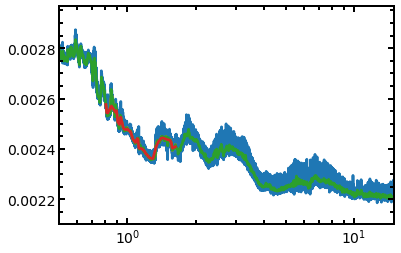

Regenerating spectra 101
1.435459877106179e+26 23908910.089533567 0.003481980489701073 16.75957141224452 110557.37179874138
Regenerating spectra 102
2.619953456721738e+26 24589956.138548233 0.0024058549463634336 28.918081416490207 111347.26570885937
Regenerating spectra 103
1.678917949961775e+26 24026568.138378736 0.0054305748346062345 19.41053008867513 77344.53029138506
Regenerating spectra 104
1.66596662073236e+26 24291971.038267337 0.0023155770189431314 18.842225385472478 143670.36016307527
Regenerating spectra 105
2.882412671608806e+26 24243333.77107632 0.014880022121354978 32.73127214407124 9188.438527891465
Regenerating spectra 106
2.8727763990404725e+26 24518959.40167839 0.0026673950531132676 31.892543991997435 81730.95402666698
Regenerating spectra 107
1.4853917045782153e+26 24744932.944877937 0.005198999444903686 16.190484296346664 75950.96123763274
Regenerating spectra 108
1.7297606874006612e+26 24282807.65690408 0.002299181257066968 19.57850971870322 72776.57190518957
Regene

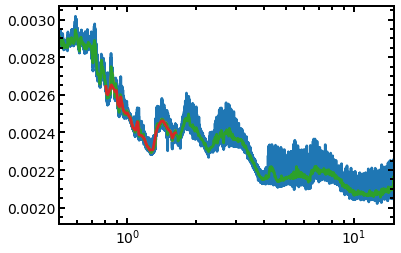

Regenerating spectra 151
2.709856967233007e+26 23891529.098961655 0.00230031952357706 31.684720759616937 86374.69768211684
Regenerating spectra 152
2.06307656072328e+26 23709667.068417568 0.002346562979002874 24.49378163437872 108272.52548016445
Regenerating spectra 153
2.777491335796034e+26 23218945.99049203 0.002316127568582427 34.38421536149854 56711.51463092418
Regenerating spectra 154
7.698208619461332e+25 24174773.23188795 0.010268288719661506 8.791364087834172 55125.38641475188
Regenerating spectra 155
2.216137804890665e+26 23840667.10778529 0.0023990674624360148 26.022640571089173 114710.00148759794
Regenerating spectra 156
2.4452941339972445e+26 23998497.596468538 0.0023155777315045957 28.337034975023535 103275.16272923892
Regenerating spectra 157
2.1765974273943332e+26 23896456.628257 0.0025966524084938816 25.43914453065781 45154.958296834884
Regenerating spectra 158
2.4133671389801435e+26 23966393.296635244 0.0029725771552002395 28.042029325875603 76015.18997913154
Regenerat

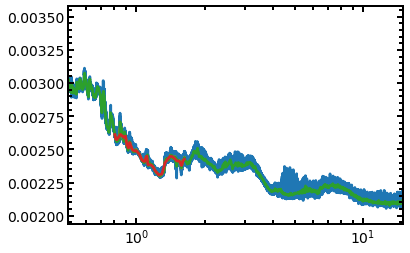

Regenerating spectra 201
1.6588099928771632e+26 23069766.726675466 0.002307615207787952 20.801834884252457 126975.06455750698
Regenerating spectra 202
2.6696795548936236e+26 23287890.837800812 0.003103051889649522 32.8541495964382 53133.24253015883
Regenerating spectra 203
1.9470135430431027e+26 23748788.82480791 0.002327696006675842 23.039733377677663 65346.57671852497
Regenerating spectra 204
2.5644005686711048e+26 23787612.55213378 0.006041330851276334 30.246530164325716 14935.791678071555
Regenerating spectra 205
2.4994980707873283e+26 24292399.01140895 0.002305445511760063 28.268541512531137 117878.05010834825
Regenerating spectra 206
2.4860066076996387e+26 25066535.102831148 0.0023004393763688224 26.4061492633242 87701.16693885259
Regenerating spectra 207
9.014764002360215e+25 23974422.139250543 0.012373538144912002 10.467656767166343 17695.17715003164
Regenerating spectra 208
9.819313307836545e+25 23828732.538214087 0.0022983898858067718 11.541722818603645 120146.48723241039
Reg

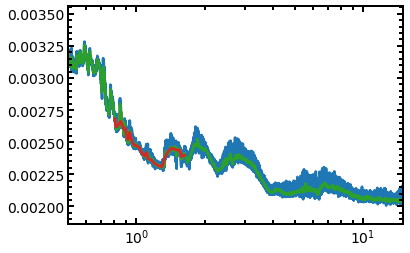

Regenerating spectra 251
1.6018311637744963e+26 24080668.04688109 0.009591368177933053 18.4361861612636 17918.894303103443
Regenerating spectra 252
1.8076007441287404e+26 23504152.150089867 0.0033088329580450815 21.837591614054908 62344.96498122169
Regenerating spectra 253
1.3186255779676134e+26 23388451.991140798 0.0031544180877566587 16.088292275250726 80008.59836593486
Regenerating spectra 254
1.5078208312477658e+26 23326526.68269612 0.0025481867913540648 18.494431780833718 75003.13124456204
Regenerating spectra 255
2.5104632042810562e+26 24131623.747089 0.002659207862259357 28.772140859255952 65789.40197252238
Regenerating spectra 256
2.9299484129984672e+26 24237521.390686788 0.002324828323746498 33.28702416111145 25423.03050259437
Regenerating spectra 257
1.5153849317123732e+26 23715688.262613934 0.004570678750367265 17.98220343520225 74849.8666436273
Regenerating spectra 258
1.6639658985712108e+26 23810456.354575086 0.0024339085183526952 19.58846438033569 153229.56395076672
Regen

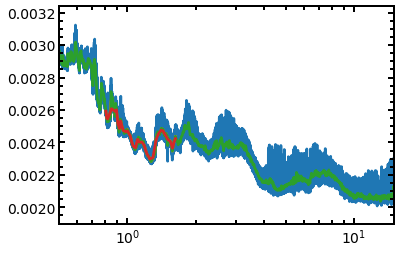

Regenerating spectra 301
2.491530967038801e+26 23773903.030651256 0.004537954922849728 29.42095213820162 25091.196296361017
Regenerating spectra 302
2.6231804200061288e+26 24453782.822477832 0.002409303535614856 29.277060379334507 53514.80131184946
Regenerating spectra 303
2.8443349314950006e+26 25333741.257210217 0.002310827567667683 29.578318544278158 99981.12516777452
Regenerating spectra 304
2.625877432571057e+26 24565887.386779584 0.0026131803751676904 29.040289771879163 67220.78355956542
Regenerating spectra 305
1.2412656028896343e+26 23112124.684316646 0.01422900933139939 15.508735359877035 19660.373000701693
Regenerating spectra 306
1.9317039920770445e+26 23423849.976394415 0.004008136039198977 23.497163007352174 41727.720618120395
Regenerating spectra 307
2.579536130627603e+26 23554074.210519493 0.0023276437439853893 31.031369691134 71759.27126703417
Regenerating spectra 308
1.5192275483702021e+26 24231934.36749638 0.005179637687133612 17.26784202878138 86944.26049205668
Regen

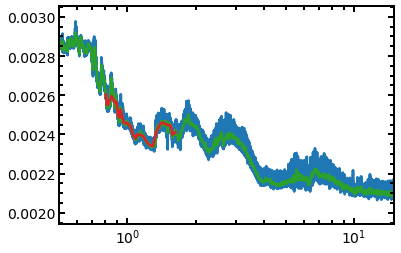

Regenerating spectra 351
2.328636339594373e+26 24888919.161431096 0.002327327687709711 25.088864409465742 58079.2367512433
Regenerating spectra 352
2.8379733701107927e+26 23425283.0836135 0.002458417417972439 34.51676044109366 78045.26217843949
Regenerating spectra 353
2.1640277349832454e+26 24950076.262587238 0.002983946073459251 23.201201494159076 38055.73272004143
Regenerating spectra 354
1.1017111156991173e+26 23320239.993700743 0.002951692139733441 13.520511076899231 82628.74419394456
Regenerating spectra 355
2.3260999946469174e+26 24400648.347789057 0.0023573376847807978 26.07456405952323 91448.7815618212
Regenerating spectra 356
2.4122188215231643e+26 23759487.92290518 0.0025306337034566757 28.518977943951835 45708.255532604686
Regenerating spectra 357
1.4444953097254654e+26 24162766.087120656 0.004685577508418654 16.512553771195556 71467.51306877797
Regenerating spectra 358
1.5960129417380746e+26 23828597.429064542 0.014316923023360222 18.759914572707956 23782.001136950927
Rege

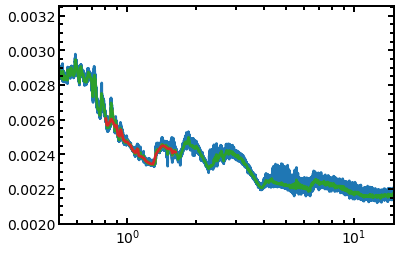

Regenerating spectra 401
2.502791236118769e+26 23856883.087762613 0.0023048134748138165 29.348683792211858 38479.00686103453
Regenerating spectra 402
2.965806776715764e+26 23318685.819558408 0.0025397837766644514 36.4020732419797 62850.46986250525
Regenerating spectra 403
1.0475332031340332e+26 23654145.84547121 0.0022988126886893663 12.495241810481556 97076.9448972838
Regenerating spectra 404
2.8433567246258634e+26 23406004.51575832 0.0024602482262815703 34.63922672286153 77810.04300801131
Regenerating spectra 405
2.6993167317330163e+26 23371943.90374808 0.002536525876060195 32.98037460554996 85285.11270492563
Regenerating spectra 406
2.7673265283158497e+26 23750736.575494654 0.0023474805685806802 32.741430396298874 55041.70229583071
Regenerating spectra 407
2.2333161463993043e+26 24629950.712132163 0.0023793270463025595 24.570530216002005 100724.8925753235
Regenerating spectra 408
2.418786862979066e+26 24532687.620351166 0.0023431400417130025 26.82246896417977 86343.14115947172
Regen

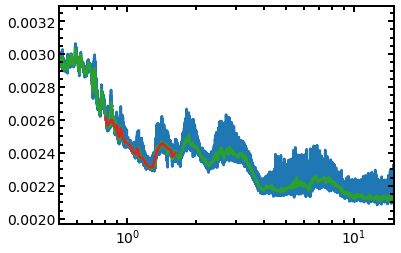

Regenerating spectra 451
1.598883259578877e+26 23515812.508286417 0.003066781978356963 19.29692841407601 72847.20050908234
Regenerating spectra 452
1.221712523950389e+26 23968382.93155403 0.005698906968971609 14.193286352040184 72815.828012644
Regenerating spectra 453
2.254436775647429e+26 23596787.49892897 0.002980291477643903 27.022386746994492 95784.84118073164
Regenerating spectra 454
2.141372144189993e+26 23694285.606883265 0.0024336093819934995 25.456360867388508 63806.135697650905
Regenerating spectra 455
2.5731235138701957e+26 23993181.139948405 0.003703999972842551 29.83158824790633 47462.72242035092
Regenerating spectra 456
2.9463457422272143e+26 24096508.273693494 0.002317526752976263 33.8662325135984 44610.30529373739
Regenerating spectra 457
2.368307766067414e+26 24466309.36868649 0.0023097950489752374 26.405392129783422 72460.43097487644
Regenerating spectra 458
1.1334844296662863e+26 24170947.12330293 0.002429887527084994 12.94850504202985 115880.20993646742
Regenerating

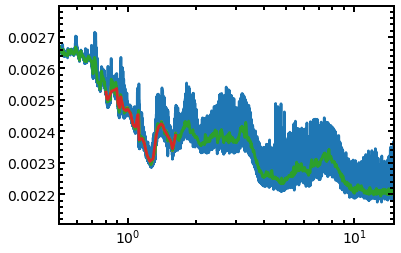

Regenerating spectra 501
2.822332278773684e+26 24197483.194181435 0.002372878015589355 32.17059972256605 81458.91959273187
Regenerating spectra 502
2.927318147821475e+26 23888424.5078988 0.002386695716308809 34.236260098940704 60360.19187836457
Regenerating spectra 503
2.9653194367856186e+26 23574928.780037537 0.0027694275637192177 35.60919152750724 77689.75996433351
Regenerating spectra 504
2.4847654281684212e+26 25106601.671123244 0.0034156262259503116 26.308793932759983 38993.68827657872
Regenerating spectra 505
2.229975620555598e+26 24416564.82375479 0.002684061293194556 24.964472711519658 85964.03955040006
Regenerating spectra 506
2.8647307316648545e+26 24055478.640233576 0.0024203588274332626 33.04054557085162 92334.09616765461
Regenerating spectra 507
2.6522541582323383e+26 23933950.857001476 0.004867861317999401 30.901371637065257 28400.63874195051
Regenerating spectra 508
1.1464094684683493e+26 23509591.883711275 0.002625531675395499 13.843343405854611 101342.66602661257
Regen

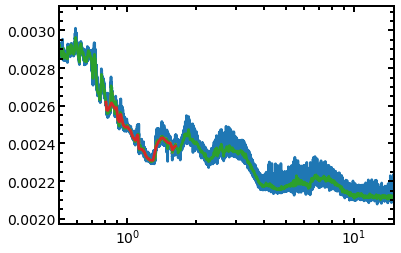

Regenerating spectra 551
1.8002836742607506e+26 24264406.99360597 0.002314297420733213 20.407649534471748 65587.68643465376
Regenerating spectra 552
2.286804997643211e+26 24893953.38214586 0.0025096905467797705 24.628207097612133 31713.71899200352
Regenerating spectra 553
1.647335603924143e+26 24640611.99262973 0.0022999283243411344 18.108001127779016 72878.90373306615
Regenerating spectra 554
2.5965024446370296e+26 24301539.274517253 0.0022986543888668435 29.343544873771318 85311.94676086363
Regenerating spectra 555
2.491973502940617e+26 23774026.69312217 0.0022980501571908 29.425871647298123 102674.09184209596
Regenerating spectra 556
8.86970052958381e+25 24957671.16286103 0.009695038548412253 9.503689711518565 23236.891910488357
Regenerating spectra 557
6.01574443040088e+25 24485593.22885856 0.0023232629319315076 6.696679663323301 168458.555885122
Regenerating spectra 558
6.081876436627344e+25 24287457.564547718 0.01613829186743421 6.881211254563588 35654.23188087281
Regenerating sp

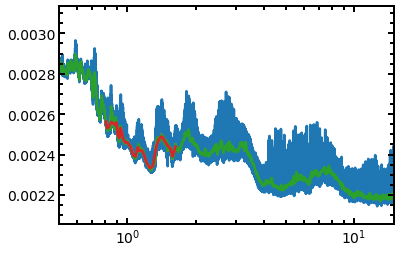

Regenerating spectra 601
1.8376203181419496e+26 23853261.115964897 0.00229995302742096 21.555180680347235 46111.2241846525
Regenerating spectra 602
2.2617780599507766e+26 23459278.501119174 0.017138946139001212 27.429133790822807 8169.302392278843
Regenerating spectra 603
1.635169440405563e+26 25023425.41864905 0.00780767983179838 17.42852571096569 37733.672478869325
Regenerating spectra 604
2.302797588969546e+26 23823852.361319743 0.0024630316450809076 27.078412267560783 62160.676395551876
Regenerating spectra 605
2.7911238841260013e+26 23974044.826399345 0.002513705550882517 32.41066150528829 57379.32916660559
Regenerating spectra 606
1.1707416060796474e+26 23959048.86564084 0.006567667119924081 13.611729632656735 71042.1968518404
Regenerating spectra 607
1.8568302424197264e+26 23960337.0066184 0.0032620756183393837 21.586277939172692 65378.77604170168
Regenerating spectra 608
1.7785889963888124e+26 23493991.486939967 0.004451647825500617 21.50569068739376 73610.85776091112
Regenerat

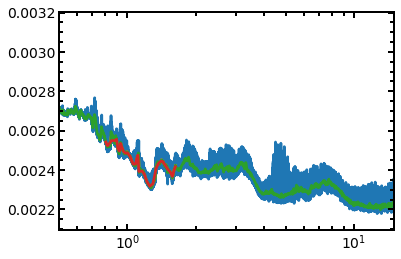

Regenerating spectra 651
2.8867258944225214e+26 24055996.36117296 0.0023242657459432103 33.29279504647217 94855.35438929881
Regenerating spectra 652
1.280555453297824e+26 23436997.09315586 0.0027568173880016694 15.559149929268797 149295.92669089622
Regenerating spectra 653
2.6581107040177256e+26 22791103.88386013 0.003984874909706451 34.15338478285642 53944.578434333394
Regenerating spectra 654
2.199663910290594e+26 24500895.781677507 0.0037064254273057925 24.455909104805265 29652.864488509033
Regenerating spectra 655
1.3489390547305805e+26 23900652.566678897 0.005867590309338999 15.760290530402752 34598.29256392463
Regenerating spectra 656
2.600646019873301e+26 24079831.77582685 0.00263015898947904 29.934068925153348 39158.57113589672
Regenerating spectra 657
1.4152897892976604e+26 23876458.385555804 0.005742192923380083 16.56902547084729 62233.13695024221
Regenerating spectra 658
1.2846927982088806e+26 22414727.924452387 0.0037489075046179396 17.065686147192903 117656.41374778065
Reg

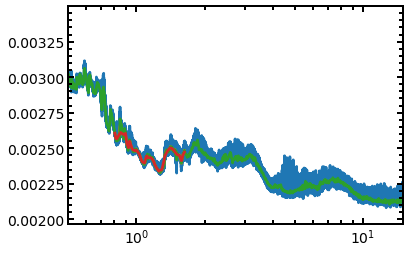

Regenerating spectra 701
1.8313995744623642e+26 24102946.128114022 0.004233665251479711 21.03944390982764 38614.045723431416
Regenerating spectra 702
1.9264940992788102e+26 24228330.63171181 0.0023334250346341598 21.903428931992636 93389.82462458922
Regenerating spectra 703
2.2921133747281804e+26 23612891.600600556 0.015810030485472148 27.436528289552104 8713.15446264686
Regenerating spectra 704
2.5184443107558377e+26 24329514.78884636 0.005402743488862355 28.39598019115734 29400.22347172782
Regenerating spectra 705
2.7023643400133947e+26 24205509.54586567 0.0023149981771281793 30.782709993101196 36300.106669094275
Regenerating spectra 706
2.6674616070733574e+26 24178832.175136454 0.0075096691866598135 30.452218953450366 22679.444025558423
Regenerating spectra 707
2.7535932060787613e+26 24028306.743719667 0.0048184326001197725 31.83060216382854 45454.496373556874
Regenerating spectra 708
2.316363600299366e+26 23561758.37482001 0.002629551965080368 27.847277578579476 104591.44444235085


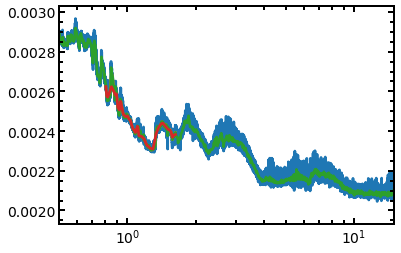

Regenerating spectra 751
1.1017111156991173e+26 23320239.993700743 0.002951692139733441 13.520511076899231 82628.74419394456
Regenerating spectra 752
1.4430566171124839e+26 23376140.318729013 0.006404400313106004 17.625001704835608 32606.835864300607
Regenerating spectra 753
1.5965803564169582e+26 23522436.5017427 0.007296357840227433 19.2582836946379 33597.135449165355
Regenerating spectra 754
1.5043621622604758e+26 23251953.120562844 0.0047272109397725635 18.570557093937733 90677.82633799479
Regenerating spectra 755
2.324563200060774e+26 23652132.038933434 0.012794739815403485 27.732701473076187 8361.100382430293
Regenerating spectra 756
1.688403341855146e+26 24004754.58151765 0.013789284844853438 19.555686695518283 23256.089224680305
Regenerating spectra 757
1.0042597653878121e+26 23204108.36577334 0.0038394454955745483 12.448232797652524 52714.986215803336
Regenerating spectra 758
2.6791529986138247e+26 22932602.602182616 0.003577094165240771 34.00025961619039 53063.50016931419
Reg

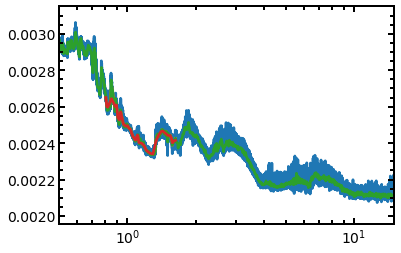

Regenerating spectra 801
2.2562274059434824e+26 22906794.44389439 0.002645723057474638 28.697604167496124 70878.72983881953
Regenerating spectra 802
1.549589428455064e+26 23279100.561135266 0.002530537962563225 19.084274745199636 119801.8753701623
Regenerating spectra 803
2.7294562948763622e+26 23566227.493237425 0.002299381494221017 32.80102545055997 50876.0889181392
Regenerating spectra 804
9.068890177914943e+25 23878615.837789744 0.0023300264138014044 10.615177330126297 153613.5742487854
Regenerating spectra 805
1.5653786551703236e+26 23540766.693143427 0.005116856542189543 18.852528649475502 78145.63279976558
Regenerating spectra 806
1.2253399311707289e+26 23707324.121770386 0.0027705272940466035 14.550667607505417 60146.144520028654
Regenerating spectra 807
1.1207398520293952e+26 24541710.632322285 0.0077304150055730915 12.418998111468644 54090.887181089834
Regenerating spectra 808
2.3500516161249475e+26 24288711.398484997 0.002325627431956657 26.586419929697403 116944.5972518823


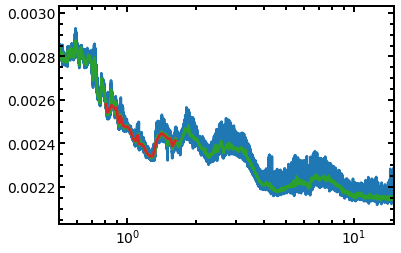

Regenerating spectra 851
1.3428045903526151e+26 24500174.03125052 0.002298542077009271 14.930208983097609 52550.72279075452
Regenerating spectra 852
2.1784858337237744e+26 24445107.18105164 0.013069390458047512 24.331128739772648 7585.353922868903
Regenerating spectra 853
1.4478197466766154e+26 24105641.998966567 0.011092395810924624 16.62909057751828 11867.53940691045
Regenerating spectra 854
6.798637228228244e+25 22989744.632511564 0.0023000742122795508 8.5850925579205 184329.39464018896
Regenerating spectra 855
2.912127062850337e+26 23759191.954144925 0.0023804028699011097 34.43010886102262 72030.51425531892
Regenerating spectra 856
1.5419009255304214e+26 23442304.76404619 0.004119057133254767 18.72609670155484 51663.665980082864
Regenerating spectra 857
1.607946083669855e+26 23875905.988377444 0.0036610514038407614 18.82535479620984 109406.09014400029
Regenerating spectra 858
1.6514686968305387e+26 23660151.528508432 0.0023426063998374163 19.689138360663314 89010.51601648529
Regene

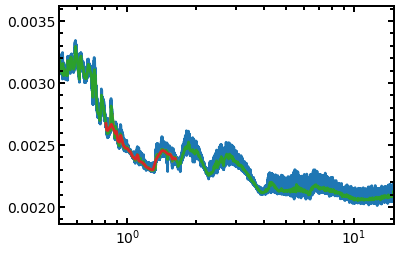

Regenerating spectra 901
2.7787653502816358e+26 24007747.50693056 0.002308514633461917 32.17662233441779 90739.71420736195
Regenerating spectra 902
2.3428894560890103e+26 23357368.98084207 0.005008070598256844 28.661265562476935 44716.12471031248
Regenerating spectra 903
2.77517951878647e+26 24273213.097802643 0.002308037735703392 31.436048671671124 34129.005208868875
Regenerating spectra 904
1.7707908579174213e+26 23982052.006445363 0.0023033864414751144 20.548777912554534 109408.8825661198
Regenerating spectra 905
2.47868678876035e+26 23977732.343714286 0.0036200180593522965 28.773775057780206 25610.54533085211
Regenerating spectra 906
2.6013087084719935e+26 24373725.37268783 0.0030006060884626095 29.223987671413713 77984.91984347961
Regenerating spectra 907
1.6258456349521514e+26 24476630.19622328 0.002912885514883266 18.11204400545689 80731.74039947345
Regenerating spectra 908
2.1951646489598898e+26 23239547.065641694 0.0023517062717717304 27.127088816522445 113905.31019983235
Rege

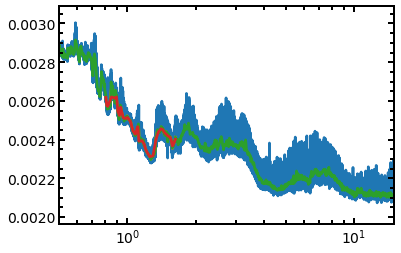

Regenerating spectra 951
7.969133122099826e+25 24225853.94826288 0.010023036694367007 9.062422393014602 32551.4222070015
Regenerating spectra 952
2.104314473468334e+26 24318133.89527241 0.0035160122113120054 23.748793960691902 53204.923434190234
Regenerating spectra 953
2.0134921885769868e+26 24741041.933949374 0.012065119650287857 21.953581773600202 13916.67351882936
Regenerating spectra 954
2.613363968998483e+26 24162068.4169017 0.010247982304964383 29.87604381757749 10783.282115454287
Regenerating spectra 955
2.5494750649540174e+26 24446660.605781876 0.002302290628341224 28.471024191300057 69183.04758058497
Regenerating spectra 956
1.896313269568812e+26 24610593.85018885 0.008032045936344658 20.895718336390253 20308.71375249632
Regenerating spectra 957
2.536335461699337e+26 24110596.8805836 0.005698812346602192 29.119383638490195 27517.489437733035
Regenerating spectra 958
1.6351605834070915e+26 22988390.272486463 0.002355391837263847 20.65069605856142 133922.2966699795
Regenerating

In [48]:
spectoutclear = {}
numsamp = min(1000,len(outclear['equal_samples'][:,0]))
shcleararr = np.zeros(numsamp)
#wavelengths_list,depths_list,info_dict_list,binwv_list,bintd_list = [],[],[],[],[]
depths_list,bintd_list,bintd_full_list = [],[],[]
for i in range(numsamp):
    print('Regenerating spectra',i)
    params = outclear['equal_samples'][i,:]
    datawv = outclear['transit_wavelengths']
    #vmrs=[]
    #for j in range(len(species)-1):
    #    vmrs.append(10.**params[j])
    #vmrs.append(1.-np.sum(vmrs))
    Rs = 0.8*R_sun
    Mp = params[2] 
    Rp = params[3] 
    T = params[4]
    logZ = params[6]
    CO_ratio = params[9]
    wavelengths, depths, info_dict = calculator.compute_depths(Rs, Mp, Rp, T, logZ=logZ, CO_ratio=CO_ratio, 
                                                               #gases=species,vmrs=vmrs, 
                                                               scattering_factor=1,
                                                               scattering_slope=4,
                                                               cloudtop_pressure=np.inf,
                                                               T_star=params[0],T_spot=params[1],
                                                               spot_cov_frac=params[5],full_output=True)
    
    # compute scale heights 
    #print(info_dict['P_profile'],10.**(params[9]+5))
    if np.max(info_dict['P_profile']) > 1e5:
        #print(len(info_dict['P_profile']),len(info_dict['mu_profile']))
        mu = interpolate.interp1d(info_dict['P_profile'],
                                  info_dict['mu_profile'][:len(info_dict['P_profile'])])(1e5)/1e3
    else:
        mu = info_dict['mu_profile'][-1]/1e3
    #print(mu)
    gr = G*Mp/Rp**2
    sh = R.value*T/(mu*gr)
    print(Mp,Rp,mu,gr,sh)
    shcleararr[i] = sh
        
    depths[0:len(wavelengths[wavelengths<datawv[n102-1]])] += params[8] 
    
    binwv = np.linspace(np.min(datawv),np.max(datawv),num=100)    
    bintd = spectres(binwv, wavelengths, depths)
        
    binwv_full = np.logspace(np.log10(0.3e-6),np.log10(15e-6),num=1000)
    bintd_full = spectres(binwv_full,wavelengths,depths)
    
    #print(bintd_full)

    if i%50 == 0:
        plt.semilogx(wavelengths*1e6,depths)
        plt.semilogx(binwv*1e6,bintd)
        plt.semilogx(binwv_full*1e6,bintd_full)
        plt.semilogx(outclear['transit_wavelengths']*1e6,outclear['random_transit_depths'][i])
        plt.xlim([0.5,15.0])
        plt.show()        

    #wavelengths_list.append(wavelengths)
    depths_list.append(depths)
    #info_dict_list.append(info_dict)
    #binwv_list.append(binwv)
    bintd_list.append(bintd)
    bintd_full_list.append(bintd_full)

spectoutclear['wavelengths'] = wavelengths
spectoutclear['depths'] = depths_list
#spectout['info_dict'] = info_dict_list
spectoutclear['binwv'] = binwv
spectoutclear['bintd'] = bintd_list
spectoutclear['binwv_full'] = binwv_full
spectoutclear['bintd_full'] = bintd_full_list

f = open('aumicb_newDataDec28_newT_clear_100PointRandomModelSpectra.pkl','wb')
pickle.dump(spectoutclear,f)
f.close()

In [ ]:
fname = 'aumicb_newDataDec28_newT_100PointRandomModelSpectra.pkl'
with open(fname,'rb') as f:
    spec = pickle.load(f)
    
fnametls = 'aumicb_newDataDec28_TLSonly_newT_100PointRandomModelSpectra.pkl'
with open(fnametls,'rb') as f:
    spectls = pickle.load(f)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd4a4bd2a90>>
Traceback (most recent call last):
  File "/data/pgao/.local/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd4a4bd2a90>>
Traceback (most recent call last):
  File "/data/pgao/.local/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd4a4bd2a90>>
Traceback (most recent call last):
  File "/data/pgao/.local/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frame

In [ ]:
spec['info_dict']

In [69]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize = (10,10), facecolor='w')
ax = axs[0]
ax1 = axs[1]
ax.errorbar(wv*1e6,td*1e2,yerr=tderr*1e2,
            ls='',color='k',marker='o',zorder=3)
#ax.set_xlabel('Wavelength ($\mu$m)')
ax.set_ylabel('Transit Depth (%)')  
ax.set_ylim([0.215,0.285])
ax1.errorbar(wv*1e6,td*1e2,yerr=tderr*1e2,
            ls='',color='k',marker='o',zorder=3,
            markersize=3,markeredgewidth=0.5,elinewidth=0.5)
ax1.set_xlabel('Wavelength ($\mu$m)')
ax1.set_ylabel('Transit Depth (%)')  
ax1.set_xlim([0.3,12])
ax1.set_ylim([0.195,0.34])

#ax1.set_xticklabels([])
#ax1.set_ylim([0.215,0.285])
#ax.set_ylim([1.1,1.16])


lower_spectrum_1sig = np.percentile(spec['bintd'], 15.865, axis=0)
upper_spectrum_1sig = np.percentile(spec['bintd'], 84.135, axis=0)
#lower_spectrum_2sig = np.percentile(spec['bintd'], 2.275, axis=0)
#upper_spectrum_2sig = np.percentile(spec['bintd'], 97.725, axis=0)
#lower_spectrum_3sig = np.percentile(spec['bintd'], 0.135, axis=0)
#upper_spectrum_3sig = np.percentile(spec['bintd'], 99.865, axis=0)

lower_spectrum_tls_1sig = np.percentile(spectls['bintd'], 15.865, axis=0)
upper_spectrum_tls_1sig = np.percentile(spectls['bintd'], 84.135, axis=0)
#lower_spectrum_tls_2sig = np.percentile(spectls['bintd'], 2.275, axis=0)
#upper_spectrum_tls_2sig = np.percentile(spectls['bintd'], 97.725, axis=0)
#lower_spectrum_tls_3sig = np.percentile(spectls['bintd'], 0.135, axis=0)
#upper_spectrum_tls_3sig = np.percentile(spectls['bintd'], 99.865, axis=0)

lower_spectrum_full_1sig = np.percentile(spec['bintd_full'], 15.865, axis=0)
upper_spectrum_full_1sig = np.percentile(spec['bintd_full'], 84.135, axis=0)

lower_spectrum_tls_full_1sig = np.percentile(spectls['bintd_full'], 15.865, axis=0)
upper_spectrum_tls_full_1sig = np.percentile(spectls['bintd_full'], 84.135, axis=0)


#ax.fill_between(spec['binwv']*1e6,
#                 lower_spectrum_3sig*1e2,
#                 upper_spectrum_3sig*1e2,
#                 color='xkcd:azure',zorder=0,alpha=0.2)
#ax.fill_between(spec['binwv']*1e6,
#                 lower_spectrum_2sig*1e2,
#                 upper_spectrum_2sig*1e2,
#                 color='xkcd:azure',zorder=1,alpha=0.5)
ax.fill_between(spec['binwv']*1e6,
                 lower_spectrum_1sig*1e2,
                 upper_spectrum_1sig*1e2,
                 color='xkcd:azure',zorder=2,alpha=0.7)


#ax.fill_between(spectls['binwv']*1e6,
#                 lower_spectrum_tls_3sig*1e2,
#                 upper_spectrum_tls_3sig*1e2,
#                 color='xkcd:tomato',zorder=0,alpha=0.2)
#ax.fill_between(spectls['binwv']*1e6,
#                 lower_spectrum_tls_2sig*1e2,
#                 upper_spectrum_tls_2sig*1e2,
#                 color='xkcd:tomato',zorder=1,alpha=0.5)
ax.fill_between(spectls['binwv']*1e6,
                 lower_spectrum_tls_1sig*1e2,
                 upper_spectrum_tls_1sig*1e2,
                 color='xkcd:vermillion',zorder=2,alpha=0.7)

ax1.fill_between(spec['binwv_full']*1e6,
                 lower_spectrum_full_1sig*1e2,
                 upper_spectrum_full_1sig*1e2,
                 color='xkcd:azure',zorder=2,alpha=0.7)

ax1.fill_between(spectls['binwv_full']*1e6,
                 lower_spectrum_tls_full_1sig*1e2,
                 upper_spectrum_tls_full_1sig*1e2,
                 color='xkcd:vermillion',zorder=2,alpha=0.7)

ax1.axvspan(2.432,4.013,edgecolor=None,facecolor='Gold',alpha=0.2)
ax1.axvspan(3.881,4.982,edgecolor=None,facecolor='Purple',alpha=0.2)


ax1.set_xscale('log')
ax1.set_xticks([0.3,0.5,0.7,1,2,3,4,5,8,10])
ax1.set_xticklabels([0.3,0.5,0.7,1,2,3,4,5,8,10])

ax.plot([1.3,1.6],[0.262-0.005,0.262-0.005],color='k')
#ax.plot([0.8,1.2],[0.287,0.287],color='k')

ax.annotate('H$_2$O + CH$_4$',xy=(1,0.25),xytext=(0.5*(1.3+1.6),0.263-0.005),color='k',fontsize=12,
             verticalalignment='bottom',horizontalalignment='center') 
#ax.annotate('TLS',xy=(1,0.25),xytext=(1.0,0.288),color='k',fontsize=12,
#             verticalalignment='bottom',horizontalalignment='center') 

ax.annotate('Full Model',xy=(1,0.25),xytext=(1.6,0.274),color='xkcd:azure',fontsize=15,
             verticalalignment='bottom',horizontalalignment='right') 
ax.annotate('TLS Only',xy=(1,0.25),xytext=(1.6,0.268),color='xkcd:vermillion',fontsize=15,
             verticalalignment='bottom',horizontalalignment='right') 

ax1.annotate('HST',xy=(1,0.25),xytext=(1e6*np.sqrt(np.min(spec['binwv'])*np.max(spec['binwv'])),0.27),
            color='k',fontsize=15,verticalalignment='bottom',horizontalalignment='center') 
ax1.annotate('JWST',xy=(1,0.25),xytext=(np.sqrt(2.432*4.958),0.323),
            color='k',fontsize=15,verticalalignment='bottom',horizontalalignment='center') 
ax1.annotate('NIRCam',xy=(1,0.25),xytext=(np.sqrt(2.432*4.958),0.31),
            color='k',fontsize=15,verticalalignment='bottom',horizontalalignment='center') 
ax1.annotate('F322W2',xy=(1,0.25),xytext=(np.sqrt(2.432*4.013),0.275),rotation=90,
            color='xkcd:goldenrod',fontsize=15,verticalalignment='center',horizontalalignment='center') 
ax1.annotate('F444W',xy=(1,0.25),xytext=(np.sqrt(3.881*4.982),0.275),rotation=90,
            color='Purple',fontsize=15,verticalalignment='center',horizontalalignment='center') 

plt.savefig('fig_newDataDec28_newT_retrieval.png', format = 'png')
plt.savefig('fig_newDataDec28_newT_retrieval.pdf', format = 'pdf')
plt.close() 

# corner plot 

print(out.equal_samples[0,:])
pnames = ['T$_{\\rm p}$ (K)','T$_{\\rm s}$ (K)','M$_{\\rm p}$ (M$_{\oplus}$)',
          'R$_{\\rm p}$ (R$_{\oplus}$)','T (K)','log(f)',
          '$m_{\\rm s}$','f$_{\\rm s}$','${\\rm [M/H]}$ ($\\times$ Solar)',
          'log(P$_{\\rm c}$) (bar)','$\epsilon^{\prime}$ (ppm)','$\Delta D$ (ppm)','C/O']
titles = ['T$_{\\rm p}$','T$_{\\rm s}$','M$_{\\rm p}$','R$_{\\rm p}$',
          'T','logf','$m_{\\rm s}$','f$_{\\rm s}$',
          '${\\rm [M/H]}$','logP$_{\\rm c}$','$\epsilon^{\prime}$','$\Delta D$','C/O']
#titlefmt = ['.0f','.0f','.0f','.0f','.0f','.0f','.0f','.2f','.0f','.0f','.0f','.0f','.0f']

fig = plt.figure(figsize=(26,26))
fig1 = corner.corner(out.equal_samples,
                    range=[0.99] * out.equal_samples.shape[1],
                    show_titles=True, levels=[0.393, 0.865, 0.989],
                    #labels=out.fit_info.fit_param_names,
                    labels=pnames,fig=fig,#title_fmt=titlefmt,
                    titles=titles,color='xkcd:deep sea blue',
                    title_kwargs={'pad':0.5,'fontdict':{'fontsize':15}},
                    quantiles=[0.16,0.5,0.86])

fig1.savefig('fig_platoncorner.png',facecolor='w')
fig1.savefig('fig_platoncorner.pdf',facecolor='w')
plt.close()



[ 3.89267381e+03  3.02024122e+03  2.87446716e+01  3.66923153e+00
  4.33388331e+02  1.23980096e+00  5.14845636e+00  3.44635308e-01
 -3.06189101e-01 -5.50930227e+00  2.18902926e+01  4.71565763e+01
  6.21681551e-01]


In [43]:
# scale height vs. cloud top pressure
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (5,5), facecolor='w')

ct = az.plot_kde(sharr/1e3,np.log10(pcldarr),
                 hdi_probs=[0.393, 0.865, 0.989],ax=ax,
                 contourf_kwargs={'colors': ['w','xkcd:azure','xkcd:cerulean','xkcd:ocean blue'], 'alpha': 1},
                 contour_kwargs={'colors': ['xkcd:ocean blue','xkcd:azure','xkcd:cerulean']})

#ct = az.plot_kde(np.log10(mettot5me/M0),ctoo5me,
#                 hdi_probs=[0.393, 0.865, 0.989],ax=ax2,
#                 contourf_kwargs={'colors': colors[ii], 'alpha': 0.3},
#                 contour_kwargs={'colors': colors[ii]}) 

#ax2.annotate(annotes[ii],xy=(1,0.5),xytext=(-0.7,0.45-ii*0.05),color=colors[ii],horizontalalignment='left') 

#ax.axhline(0.59,color='k',linestyle='--')
#ax.axvline(0,color='gray',linestyle='--')
#ax2.axhline(0.59,color='gray',linestyle='--')

#ax1.set_ylim([0,0.65])
#ax.set_xlim([0,3])

#ax1.annotate('Outside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 
#ax2.annotate('Inside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 

#ax.annotate('Solar C/O',xy=(0,0.5),xytext=(1.25,0.63),color='k',
#             horizontalalignment='center',fontsize=12) 
#ax2.annotate('Solar C/O = 0.59 (Asplund et al. 2021)',xy=(0,0.5),xytext=(1,0.56),color='gray',
#             horizontalalignment='center') 

ax.set_xlabel('Scale Height (km)')
ax.set_ylabel('Cloud Top Pressure')

plt.savefig('fig_newT_shpcld.png', format = 'png')
plt.savefig('fig_newT_shpcld.pdf', format = 'pdf')
plt.close()

In [110]:
# scale height vs. cloud top pressure
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (5,5), facecolor='w')

print(np.max(sharr),np.min(sharr))

ct = az.plot_dist(sharr/1e3,color='xkcd:azure',ax=ax,quantiles=[0.5])

ax.axvline(np.median(sharr/1e3),color='k',linestyle='--')
#ax.axvline(np.percentile(sharr/1e3, 15.865),color='k',linestyle=':')
#ax.axvline(np.percentile(sharr/1e3, 84.135),color='k',linestyle=':')
ax.axvline(np.percentile(sharr/1e3, 99.865),color='Tomato',linestyle=':')

#print(np.median(sharr/1e3),np.median(sharr/1e3)-np.percentile(sharr/1e3, 15.865),
#      np.percentile(sharr/1e3, 84.135)-np.median(sharr/1e3))

print(np.median(sharr/1e3),np.percentile(sharr/1e3, 99.865))

ax.set_xlim([10,192])
ax.set_ylim([0,0.015])

#ax1.annotate('Outside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 
#ax2.annotate('Inside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 

#ax.set_title('H = 52$^{+38}_{-27}$ km',color='k',pad=10) 
#ax2.annotate('Solar C/O = 0.59 (Asplund et al. 2021)',xy=(0,0.5),xytext=(1,0.56),color='gray',
#             horizontalalignment='center') 

ax.annotate('Median',xy=(50,0),xytext=(45,0.006),color='k',
             horizontalalignment='center',verticalalignment='center',rotation=90) 
ax.annotate('3$\sigma$',xy=(50,0),xytext=(179,0.006),color='Tomato',
             horizontalalignment='center',verticalalignment='center',rotation=90) 

ax.set_xlabel('Scale Height (km)')
ax.set_ylabel('PDF')

plt.savefig('fig_newT_sh.png', format = 'png')
plt.savefig('fig_newT_sh.pdf', format = 'pdf')
plt.close()

191213.74775245227 6161.603407626301
51.81617816436224 184.80493263610273


In [ ]:
# metallicity vs. C/O
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (5,5), facecolor='w')

ct = az.plot_kde(out['equal_samples'][:,8],out['equal_samples'][:,12],
                 hdi_probs=[0.393, 0.865, 0.989],ax=ax,
                 contourf_kwargs={'colors': ['w','xkcd:azure','xkcd:cerulean','xkcd:ocean blue'], 'alpha': 1},
                 contour_kwargs={'colors': ['xkcd:ocean blue','xkcd:azure','xkcd:cerulean']})

#ct = az.plot_kde(np.log10(mettot5me/M0),ctoo5me,
#                 hdi_probs=[0.393, 0.865, 0.989],ax=ax2,
#                 contourf_kwargs={'colors': colors[ii], 'alpha': 0.3},
#                 contour_kwargs={'colors': colors[ii]}) 

#ax2.annotate(annotes[ii],xy=(1,0.5),xytext=(-0.7,0.45-ii*0.05),color=colors[ii],horizontalalignment='left') 

ax.axhline(0.59,color='k',linestyle='--')
#ax.axvline(0,color='gray',linestyle='--')
#ax2.axhline(0.59,color='gray',linestyle='--')

#ax1.set_ylim([0,0.65])
ax.set_xlim([0,3])

#ax1.annotate('Outside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 
#ax2.annotate('Inside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 

ax.annotate('Solar C/O',xy=(0,0.5),xytext=(1.25,0.63),color='k',
             horizontalalignment='center',fontsize=12) 
#ax2.annotate('Solar C/O = 0.59 (Asplund et al. 2021)',xy=(0,0.5),xytext=(1,0.56),color='gray',
#             horizontalalignment='center') 

ax.set_ylabel('C/O')
ax.set_xlabel('[M/H]')

plt.savefig('fig_newT_metc2oposteriors.png', format = 'png')
plt.savefig('fig_newT_metc2oposteriors.pdf', format = 'pdf')
plt.close()

In [3]:
def readInDataEur(fn):
    infile = open(fn,'r')
    lines = infile.readlines()[1:]
    infile.close()
    nl = len(lines)
    wv_,td_,tderr_ = np.zeros(nl),np.zeros(nl),np.zeros(nl)
    wvbins_ = np.zeros((nl,2))
    for i in range(nl):
        line = lines[i].split(',')
        wv_[i] = round(float(line[0]),3)/1e6 # micron -> m, round to 3 decimal places to remove numerical stuff
        binhalfwid = round(float(line[1]),3)/1e6 # micron -> m, round to 3 decimal places to remove numerical stuff
        wvbins_[i,0] = wv_[i]-binhalfwid # m
        wvbins_[i,1] = wv_[i]+binhalfwid # m
        td_[i] = float(line[2]) # transit depth 
        tderr_[i] = max(float(line[3]),float(line[4])) # larger of the asymmetric transit depth errors (conservative option)
    nnrs1_ = 0
    for i in range(nl-1):
        if wv_[i+1]-wv_[i] < binhalfwid*3.:
            nnrs1_ += 1
        else:
            nnrs1_final = nnrs1_
    return wv_,wvbins_,td_,tderr_,nnrs1_final

def readInDataTib(fn):
    infile = open(fn,'r')
    lines = infile.readlines()[1:]
    infile.close()
    nl = len(lines)
    wv_,td_,tderr_ = np.zeros(nl),np.zeros(nl),np.zeros(nl)
    wvbins_ = np.zeros((nl,2))
    for i in range(nl):
        line = lines[i].split()
        wv_[i] = float(line[0])/1e6 # micron -> m
        binfullwid = float(line[1])/1e6 # micron -> m
        wvbins_[i,0] = wv_[i]-binfullwid/2.
        wvbins_[i,1] = wv_[i]+binfullwid/2.
        td_[i] = float(line[2])/1e6 # ppm -> nothing 
        tderr_[i] = float(line[3])/1e6 # ppm -> nothing 
    nnrs1_ = 0
    for i in range(nl-1):
        if wv_[i+1]-wv_[i] < binfullwid*1.5:
            nnrs1_ += 1
        else:
            nnrs1_final = nnrs1_
    return wv_,wvbins_,td_,tderr_,nnrs1_final

def readInDataTsw(fn):
    infile = open(fn,'r')
    lines = infile.readlines()[1:]
    infile.close()
    nl = len(lines)
    wv_,td_,tderr_ = np.zeros(nl),np.zeros(nl),np.zeros(nl)
    wvbins_ = np.zeros((nl,2))
    for i in range(nl):
        line = lines[i].split(',')
        wv_[i] = float(line[0])/1e6 # micron -> m
        td_[i] = float(line[1])/1e6 # ppm -> nothing 
        tderr_[i] = float(line[2])/1e6 # ppm -> nothing 
    binhalfwid = (wv_[1]-wv_[0])/2. # assuming bin width is constant with wavelength
    for i in range(nl):
        wvbins_[i,0] = wv_[i]-binhalfwid
        wvbins_[i,1] = wv_[i]+binhalfwid
    nnrs1_ = 0
    for i in range(nl-1):
        if wv_[i+1]-wv_[i] < binhalfwid*3.:
            nnrs1_ += 1
        else:
            nnrs1_final = nnrs1_
    return wv_,wvbins_,td_,tderr_,nnrs1_final

In [4]:
# Read in data
dfiles,wv,wvbins,td,tderr,nnrs1 = {},{},{},{},{},{}
dfiles['eureka'] = {}
dfiles['eureka']['10nm'] = 'data/Eureka/S6_TOI2031b_Eureka_Transmission_Spectrum_10nm_bins_v1.csv'
dfiles['eureka']['50nm'] = 'data/Eureka/S6_TOI2031b_Eureka_Transmission_Spectrum_50nm_bins_v1.csv'
dfiles['eureka']['20nm'] = 'data/Eureka/S6_TOI2031b_Eureka_Transmission_Spectrum_20nm_bins_v1.csv'
dfiles['tiberius'] = {}
dfiles['tiberius']['10nm'] = 'data/Tiberius/TOI-2031b_Tiberius-JK_spectrum_10nm_Nov25_depths_v1.txt'
dfiles['tiberius']['50nm'] = 'data/Tiberius/TOI-2031b_Tiberius-JK_spectrum_50nm_Nov25_depths_v1.txt'
dfiles['tiberius']['20nm'] = 'data/Tiberius/TOI-2031b_Tiberius-JK_spectrum_20nm_Nov25_depths_v1.txt'
dfiles['tswift'] = {}
dfiles['tswift']['10nm'] = 'data/Tswift/TOI-2031b_Guangwei_spectrum_binned_10nm_Nov10th_v1.csv'
dfiles['tswift']['50nm'] = 'data/Tswift/TOI-2031b_Guangwei_spectrum_binned_50nm_Nov10th_v1.csv'
dfiles['tswift']['20nm'] = 'data/Tswift/TOI-2031b_Guangwei_spectrum_binned_20nm_Nov10th_v1.csv'
wv = {x:{y:{} for y in dfiles[x]} for x in dfiles}
wvbins = {x:{y:{} for y in dfiles[x]} for x in dfiles}
td = {x:{y:{} for y in dfiles[x]} for x in dfiles}
tderr = {x:{y:{} for y in dfiles[x]} for x in dfiles}
nnrs1 = {x:{y:{} for y in dfiles[x]} for x in dfiles}

for x in dfiles:
    if x == 'eureka':
        for y in dfiles[x]:
            wv[x][y],wvbins[x][y],td[x][y],tderr[x][y],nnrs1[x][y] = readInDataEur(dfiles[x][y])
    if x == 'tiberius':
        for y in dfiles[x]:
            wv[x][y],wvbins[x][y],td[x][y],tderr[x][y],nnrs1[x][y] = readInDataTib(dfiles[x][y])
    if x == 'tswift':
        for y in dfiles[x]:
            wv[x][y],wvbins[x][y],td[x][y],tderr[x][y],nnrs1[x][y] = readInDataTsw(dfiles[x][y])


In [34]:
# Make models 

calculator = TransitDepthCalculator()

Rs=1.241 * R_sun
Mp=0.8 * M_jup 
Rp=1.248 * R_jup
#Rp=89669032.97
T=1358.

modwav_1x, modtd_1x, info_dict_1x = calculator.compute_depths(Rs, Mp, Rp, T, logZ=0, CO_ratio=0.59, 
                                                            full_output=True)
modwav_10x, modtd_10x, info_dict_10x = calculator.compute_depths(Rs, Mp, Rp, T, logZ=1, CO_ratio=0.59, 
                                                            full_output=True)

In [55]:
# Plot

# Plot settings
plt.rc('font', family='sans-serif')
fontname = 'sans-serif'
labelpad=5

# from toi260.01.mplstyle

plt.rc('lines', linewidth=2.7)              
plt.rc('lines', markerfacecolor='w')
plt.rc('lines', markeredgewidth=2.0)          
plt.rc('lines', markersize=8)  

plt.rc('font', size=17)

plt.rc('text', usetex=False)

plt.rc('axes', labelsize = 17)
plt.rc('axes', linewidth=2)
plt.rc('axes', labelweight='normal')
plt.rc('axes', axisbelow=False)

plt.rc('xtick', top=True)     
plt.rc('xtick', bottom=True)     
plt.rc('xtick.major', size=6)
plt.rc('xtick.minor', size=4)      
plt.rc('xtick.major', width=2)     
plt.rc('xtick.minor', width=2)    
plt.rc('xtick', labelsize=14)      
plt.rc('xtick', direction='in')      
plt.rc('xtick.minor', visible=True)    
plt.rc('xtick.major', top=True)    
plt.rc('xtick.major', bottom=True)    
plt.rc('xtick.minor', top=True)    
plt.rc('xtick.minor', bottom=True)   

plt.rc('ytick', left=True)     
plt.rc('ytick', right=True)     
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=4)      
plt.rc('ytick.major', width=2)     
plt.rc('ytick.minor', width=2)    
plt.rc('ytick', labelsize=14)      
plt.rc('ytick', direction='in')      
plt.rc('ytick.minor', visible=True)    
plt.rc('ytick.major', left=True)    
plt.rc('ytick.major', right=True)    
plt.rc('ytick.minor', left=True)    
plt.rc('ytick.minor', right=True)  
  
plt.rc('legend', fontsize=18)

plt.rc('image', aspect='auto')        
plt.rc('image', origin='lower')        

plt.rc('errorbar', capsize=0)

plt.rc('savefig', bbox='tight')

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,5), facecolor='w')
ax.errorbar(wv['eureka']['50nm']*1e6,td['eureka']['50nm']*1e2,yerr=tderr['eureka']['50nm']*1e2,
            ls='',color='k',marker='o',zorder=0)
ax.set_xlabel('Wavelength ($\mu$m)')
ax.set_ylabel('Transit Depth (%)')  
ax.set_ylim([1.1,1.16])
plt.savefig('fig_eureka_50nm.png', format = 'png')
#plt.savefig('fig_models_toi402.02_final2.pdf', format = 'pdf')
plt.close() 

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,5), facecolor='w')
ax.errorbar(wv['eureka']['50nm']*1e6,td['eureka']['50nm']*1e2,yerr=tderr['eureka']['50nm']*1e2,
            ls='',color='k',marker='o',zorder=0)

binwv = np.linspace(np.min(wv['eureka']['50nm']),np.max(wv['eureka']['50nm']),num=100)    
bintd = spectres(binwv, modwav_1x, modtd_1x)

ax.plot(binwv*1e6,bintd*1e2,color='DeepSkyBlue')
ax.set_xlabel('Wavelength ($\mu$m)')
ax.set_ylabel('Transit Depth (%)')  
#ax.set_ylim([550,1050])
plt.savefig('fig_eureka_50nm_1xsolmod.png', format = 'png')
#plt.savefig('fig_models_toi402.02_final2.pdf', format = 'pdf')
plt.close() 

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,5), facecolor='w')
ax.errorbar(wv['eureka']['50nm']*1e6,td['eureka']['50nm']*1e2,yerr=tderr['eureka']['50nm']*1e2,
            ls='',color='k',marker='o',zorder=0)
ax.plot(binwv*1e6,bintd*1e2,color='DeepSkyBlue')
bintd = spectres(binwv, modwav_10x, modtd_10x)
ax.plot(binwv*1e6,(bintd-0.00017)*1e2,color='Tomato')
ax.set_xlabel('Wavelength ($\mu$m)')
ax.set_ylabel('Transit Depth (%)')  
#ax.set_ylim([550,1050])
plt.savefig('fig_eureka_50nm_10xsolmod.png', format = 'png')
#plt.savefig('fig_models_toi402.02_final2.pdf', format = 'pdf')
plt.close() 

In [44]:
fname = 'retrieval_results/toi2031b_nlive1000_eqchem_hetlimb_eureka50nm.pkl'
with open(fname,'rb') as f:
    out = pickle.load(f)
print(out.keys())
print(out['labels'])
print(out['best_fit_params'])

['best_fit_params', 'retrieval_type', 'transit_bins', 'transit_depths', 'transit_errors', 'transit_wavelengths', 'transit_chi_sqr', 'transit_red_chi_sqr', 'eclipse_bins', 'eclipse_depths', 'eclipse_errors', 'best_fit_transit_depths', 'best_fit_transit_dict', 'best_fit_eclipse_depths', 'best_fit_eclipse_dict', 'fit_info', 'logZ', 'logZerr', 'samples', 'logp', 'logl', 'equal_samples', 'divisors', 'labels', 'random_transit_depths', 'random_eclipse_depths', 'random_TP_profiles', 'pointwise_lnlikes']
['R_star/R_sun' 'M_p/M_j' 'R_p/R_j' 'T' 'log_scatt_factor' 'scatt_slope'
 'logZ' 'log_cloudtop_P' 'offset_transit' 'CO_ratio' 'cloud_frac']
[8.60545652e+08 1.85017466e+27 8.91962156e+07 1.49358155e+03
 1.48085183e+00 1.08409549e+01 1.20182491e+00 4.14103253e+00
 4.74810963e-05 9.27299311e-01 7.28113789e-01]


Regenerating spectra 0


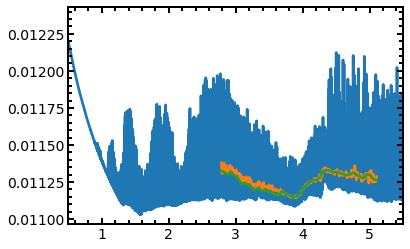

Regenerating spectra 1
Regenerating spectra 2
Regenerating spectra 3
Regenerating spectra 4
Regenerating spectra 5
Regenerating spectra 6
Regenerating spectra 7
Regenerating spectra 8
Regenerating spectra 9
Regenerating spectra 10
Regenerating spectra 11
Regenerating spectra 12
Regenerating spectra 13
Regenerating spectra 14
Regenerating spectra 15
Regenerating spectra 16
Regenerating spectra 17
Regenerating spectra 18
Regenerating spectra 19
Regenerating spectra 20
Regenerating spectra 21
Regenerating spectra 22
Regenerating spectra 23
Regenerating spectra 24
Regenerating spectra 25
Regenerating spectra 26
Regenerating spectra 27
Regenerating spectra 28
Regenerating spectra 29
Regenerating spectra 30
Regenerating spectra 31
Regenerating spectra 32
Regenerating spectra 33
Regenerating spectra 34
Regenerating spectra 35
Regenerating spectra 36
Regenerating spectra 37
Regenerating spectra 38
Regenerating spectra 39
Regenerating spectra 40
Regenerating spectra 41
Regenerating spectra 42
R

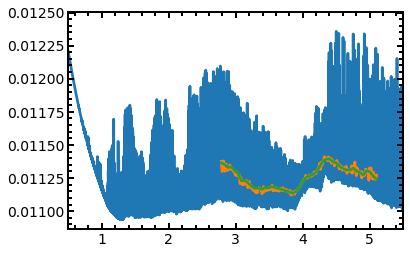

Regenerating spectra 51
Regenerating spectra 52
Regenerating spectra 53
Regenerating spectra 54
Regenerating spectra 55
Regenerating spectra 56
Regenerating spectra 57
Regenerating spectra 58
Regenerating spectra 59
Regenerating spectra 60
Regenerating spectra 61
Regenerating spectra 62
Regenerating spectra 63
Regenerating spectra 64
Regenerating spectra 65
Regenerating spectra 66
Regenerating spectra 67
Regenerating spectra 68
Regenerating spectra 69
Regenerating spectra 70
Regenerating spectra 71
Regenerating spectra 72
Regenerating spectra 73
Regenerating spectra 74
Regenerating spectra 75
Regenerating spectra 76
Regenerating spectra 77
Regenerating spectra 78
Regenerating spectra 79
Regenerating spectra 80
Regenerating spectra 81
Regenerating spectra 82
Regenerating spectra 83
Regenerating spectra 84
Regenerating spectra 85
Regenerating spectra 86
Regenerating spectra 87
Regenerating spectra 88
Regenerating spectra 89
Regenerating spectra 90
Regenerating spectra 91
Regenerating spe

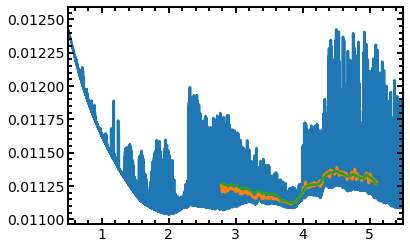

Regenerating spectra 101
Regenerating spectra 102
Regenerating spectra 103
Regenerating spectra 104
Regenerating spectra 105
Regenerating spectra 106
Regenerating spectra 107
Regenerating spectra 108
Regenerating spectra 109
Regenerating spectra 110
Regenerating spectra 111
Regenerating spectra 112
Regenerating spectra 113
Regenerating spectra 114
Regenerating spectra 115
Regenerating spectra 116
Regenerating spectra 117
Regenerating spectra 118
Regenerating spectra 119
Regenerating spectra 120
Regenerating spectra 121
Regenerating spectra 122
Regenerating spectra 123
Regenerating spectra 124
Regenerating spectra 125
Regenerating spectra 126
Regenerating spectra 127
Regenerating spectra 128
Regenerating spectra 129
Regenerating spectra 130
Regenerating spectra 131
Regenerating spectra 132
Regenerating spectra 133
Regenerating spectra 134
Regenerating spectra 135
Regenerating spectra 136
Regenerating spectra 137
Regenerating spectra 138
Regenerating spectra 139
Regenerating spectra 140


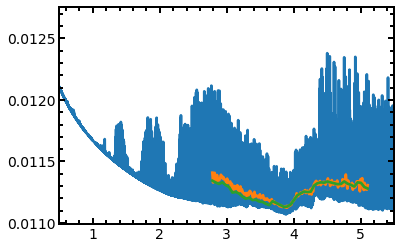

Regenerating spectra 151
Regenerating spectra 152
Regenerating spectra 153
Regenerating spectra 154
Regenerating spectra 155
Regenerating spectra 156
Regenerating spectra 157
Regenerating spectra 158
Regenerating spectra 159
Regenerating spectra 160
Regenerating spectra 161
Regenerating spectra 162
Regenerating spectra 163
Regenerating spectra 164
Regenerating spectra 165
Regenerating spectra 166
Regenerating spectra 167
Regenerating spectra 168
Regenerating spectra 169
Regenerating spectra 170
Regenerating spectra 171
Regenerating spectra 172
Regenerating spectra 173
Regenerating spectra 174
Regenerating spectra 175
Regenerating spectra 176
Regenerating spectra 177
Regenerating spectra 178
Regenerating spectra 179
Regenerating spectra 180
Regenerating spectra 181
Regenerating spectra 182
Regenerating spectra 183
Regenerating spectra 184
Regenerating spectra 185
Regenerating spectra 186
Regenerating spectra 187
Regenerating spectra 188
Regenerating spectra 189
Regenerating spectra 190


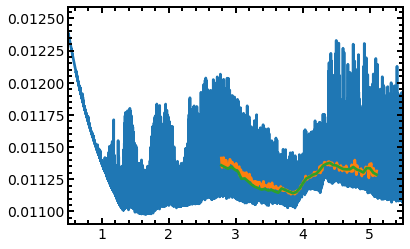

Regenerating spectra 201
Regenerating spectra 202
Regenerating spectra 203
Regenerating spectra 204
Regenerating spectra 205
Regenerating spectra 206
Regenerating spectra 207
Regenerating spectra 208
Regenerating spectra 209
Regenerating spectra 210
Regenerating spectra 211
Regenerating spectra 212
Regenerating spectra 213
Regenerating spectra 214
Regenerating spectra 215
Regenerating spectra 216
Regenerating spectra 217
Regenerating spectra 218
Regenerating spectra 219
Regenerating spectra 220
Regenerating spectra 221
Regenerating spectra 222
Regenerating spectra 223
Regenerating spectra 224
Regenerating spectra 225
Regenerating spectra 226
Regenerating spectra 227
Regenerating spectra 228
Regenerating spectra 229
Regenerating spectra 230
Regenerating spectra 231
Regenerating spectra 232
Regenerating spectra 233
Regenerating spectra 234
Regenerating spectra 235
Regenerating spectra 236
Regenerating spectra 237
Regenerating spectra 238
Regenerating spectra 239
Regenerating spectra 240


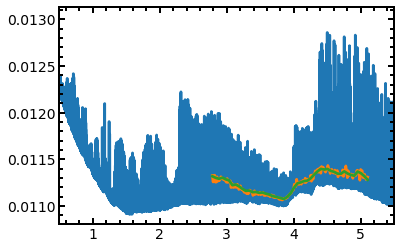

Regenerating spectra 251
Regenerating spectra 252
Regenerating spectra 253
Regenerating spectra 254
Regenerating spectra 255
Regenerating spectra 256
Regenerating spectra 257
Regenerating spectra 258
Regenerating spectra 259
Regenerating spectra 260
Regenerating spectra 261
Regenerating spectra 262
Regenerating spectra 263
Regenerating spectra 264
Regenerating spectra 265
Regenerating spectra 266
Regenerating spectra 267
Regenerating spectra 268
Regenerating spectra 269
Regenerating spectra 270
Regenerating spectra 271
Regenerating spectra 272
Regenerating spectra 273
Regenerating spectra 274
Regenerating spectra 275
Regenerating spectra 276
Regenerating spectra 277
Regenerating spectra 278
Regenerating spectra 279
Regenerating spectra 280
Regenerating spectra 281
Regenerating spectra 282
Regenerating spectra 283
Regenerating spectra 284
Regenerating spectra 285
Regenerating spectra 286
Regenerating spectra 287
Regenerating spectra 288
Regenerating spectra 289
Regenerating spectra 290


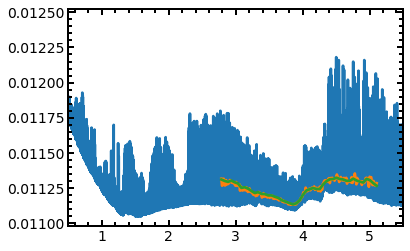

Regenerating spectra 301
Regenerating spectra 302
Regenerating spectra 303
Regenerating spectra 304
Regenerating spectra 305
Regenerating spectra 306
Regenerating spectra 307
Regenerating spectra 308
Regenerating spectra 309
Regenerating spectra 310
Regenerating spectra 311
Regenerating spectra 312
Regenerating spectra 313
Regenerating spectra 314
Regenerating spectra 315
Regenerating spectra 316
Regenerating spectra 317
Regenerating spectra 318
Regenerating spectra 319
Regenerating spectra 320
Regenerating spectra 321
Regenerating spectra 322
Regenerating spectra 323
Regenerating spectra 324
Regenerating spectra 325
Regenerating spectra 326
Regenerating spectra 327
Regenerating spectra 328
Regenerating spectra 329
Regenerating spectra 330
Regenerating spectra 331
Regenerating spectra 332
Regenerating spectra 333
Regenerating spectra 334
Regenerating spectra 335
Regenerating spectra 336
Regenerating spectra 337
Regenerating spectra 338
Regenerating spectra 339
Regenerating spectra 340


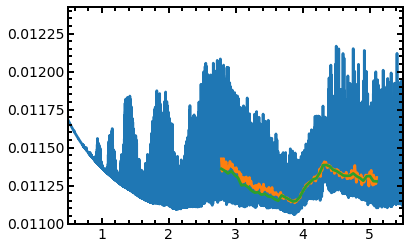

Regenerating spectra 351
Regenerating spectra 352
Regenerating spectra 353
Regenerating spectra 354
Regenerating spectra 355
Regenerating spectra 356
Regenerating spectra 357
Regenerating spectra 358
Regenerating spectra 359
Regenerating spectra 360
Regenerating spectra 361
Regenerating spectra 362
Regenerating spectra 363
Regenerating spectra 364
Regenerating spectra 365
Regenerating spectra 366
Regenerating spectra 367
Regenerating spectra 368
Regenerating spectra 369
Regenerating spectra 370
Regenerating spectra 371
Regenerating spectra 372
Regenerating spectra 373
Regenerating spectra 374
Regenerating spectra 375
Regenerating spectra 376
Regenerating spectra 377
Regenerating spectra 378
Regenerating spectra 379
Regenerating spectra 380
Regenerating spectra 381
Regenerating spectra 382
Regenerating spectra 383
Regenerating spectra 384
Regenerating spectra 385
Regenerating spectra 386
Regenerating spectra 387
Regenerating spectra 388
Regenerating spectra 389
Regenerating spectra 390


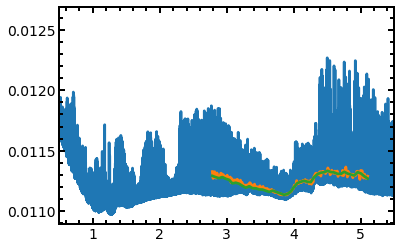

Regenerating spectra 401
Regenerating spectra 402
Regenerating spectra 403
Regenerating spectra 404
Regenerating spectra 405
Regenerating spectra 406
Regenerating spectra 407
Regenerating spectra 408
Regenerating spectra 409
Regenerating spectra 410
Regenerating spectra 411
Regenerating spectra 412
Regenerating spectra 413
Regenerating spectra 414
Regenerating spectra 415
Regenerating spectra 416
Regenerating spectra 417
Regenerating spectra 418
Regenerating spectra 419
Regenerating spectra 420
Regenerating spectra 421
Regenerating spectra 422
Regenerating spectra 423
Regenerating spectra 424
Regenerating spectra 425
Regenerating spectra 426
Regenerating spectra 427
Regenerating spectra 428
Regenerating spectra 429
Regenerating spectra 430
Regenerating spectra 431
Regenerating spectra 432
Regenerating spectra 433
Regenerating spectra 434
Regenerating spectra 435
Regenerating spectra 436
Regenerating spectra 437
Regenerating spectra 438
Regenerating spectra 439
Regenerating spectra 440


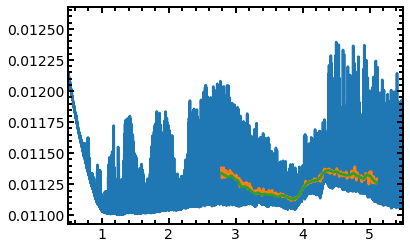

Regenerating spectra 451
Regenerating spectra 452
Regenerating spectra 453
Regenerating spectra 454
Regenerating spectra 455
Regenerating spectra 456
Regenerating spectra 457
Regenerating spectra 458
Regenerating spectra 459
Regenerating spectra 460
Regenerating spectra 461
Regenerating spectra 462
Regenerating spectra 463
Regenerating spectra 464
Regenerating spectra 465
Regenerating spectra 466
Regenerating spectra 467
Regenerating spectra 468
Regenerating spectra 469
Regenerating spectra 470
Regenerating spectra 471
Regenerating spectra 472
Regenerating spectra 473
Regenerating spectra 474
Regenerating spectra 475
Regenerating spectra 476
Regenerating spectra 477
Regenerating spectra 478
Regenerating spectra 479
Regenerating spectra 480
Regenerating spectra 481
Regenerating spectra 482
Regenerating spectra 483
Regenerating spectra 484
Regenerating spectra 485
Regenerating spectra 486
Regenerating spectra 487
Regenerating spectra 488
Regenerating spectra 489
Regenerating spectra 490


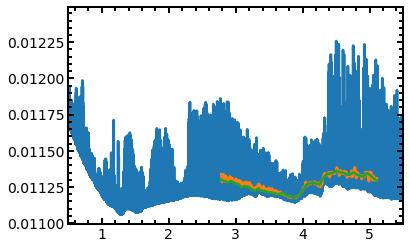

Regenerating spectra 501
Regenerating spectra 502
Regenerating spectra 503
Regenerating spectra 504
Regenerating spectra 505
Regenerating spectra 506
Regenerating spectra 507
Regenerating spectra 508
Regenerating spectra 509
Regenerating spectra 510
Regenerating spectra 511
Regenerating spectra 512
Regenerating spectra 513
Regenerating spectra 514
Regenerating spectra 515
Regenerating spectra 516
Regenerating spectra 517
Regenerating spectra 518
Regenerating spectra 519
Regenerating spectra 520
Regenerating spectra 521
Regenerating spectra 522
Regenerating spectra 523
Regenerating spectra 524
Regenerating spectra 525
Regenerating spectra 526
Regenerating spectra 527
Regenerating spectra 528
Regenerating spectra 529
Regenerating spectra 530
Regenerating spectra 531
Regenerating spectra 532
Regenerating spectra 533
Regenerating spectra 534
Regenerating spectra 535
Regenerating spectra 536
Regenerating spectra 537
Regenerating spectra 538
Regenerating spectra 539
Regenerating spectra 540


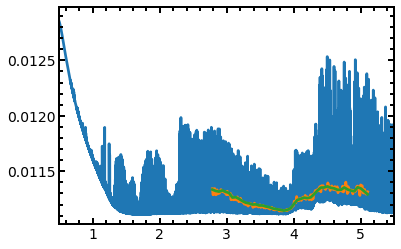

Regenerating spectra 551
Regenerating spectra 552
Regenerating spectra 553
Regenerating spectra 554
Regenerating spectra 555
Regenerating spectra 556
Regenerating spectra 557
Regenerating spectra 558
Regenerating spectra 559
Regenerating spectra 560
Regenerating spectra 561
Regenerating spectra 562
Regenerating spectra 563
Regenerating spectra 564
Regenerating spectra 565
Regenerating spectra 566
Regenerating spectra 567
Regenerating spectra 568
Regenerating spectra 569
Regenerating spectra 570
Regenerating spectra 571
Regenerating spectra 572
Regenerating spectra 573
Regenerating spectra 574
Regenerating spectra 575
Regenerating spectra 576
Regenerating spectra 577
Regenerating spectra 578
Regenerating spectra 579
Regenerating spectra 580
Regenerating spectra 581
Regenerating spectra 582
Regenerating spectra 583
Regenerating spectra 584
Regenerating spectra 585
Regenerating spectra 586
Regenerating spectra 587
Regenerating spectra 588
Regenerating spectra 589
Regenerating spectra 590


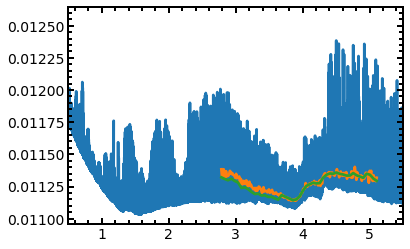

Regenerating spectra 601
Regenerating spectra 602
Regenerating spectra 603
Regenerating spectra 604
Regenerating spectra 605
Regenerating spectra 606
Regenerating spectra 607
Regenerating spectra 608
Regenerating spectra 609
Regenerating spectra 610
Regenerating spectra 611
Regenerating spectra 612
Regenerating spectra 613
Regenerating spectra 614
Regenerating spectra 615
Regenerating spectra 616
Regenerating spectra 617
Regenerating spectra 618
Regenerating spectra 619
Regenerating spectra 620
Regenerating spectra 621
Regenerating spectra 622
Regenerating spectra 623
Regenerating spectra 624
Regenerating spectra 625
Regenerating spectra 626
Regenerating spectra 627
Regenerating spectra 628
Regenerating spectra 629
Regenerating spectra 630
Regenerating spectra 631
Regenerating spectra 632
Regenerating spectra 633
Regenerating spectra 634
Regenerating spectra 635
Regenerating spectra 636
Regenerating spectra 637
Regenerating spectra 638
Regenerating spectra 639
Regenerating spectra 640


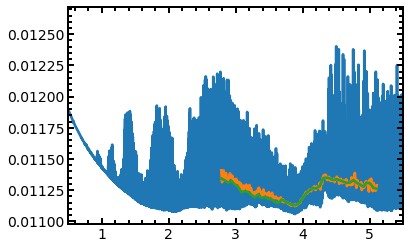

Regenerating spectra 651
Regenerating spectra 652
Regenerating spectra 653
Regenerating spectra 654
Regenerating spectra 655
Regenerating spectra 656
Regenerating spectra 657
Regenerating spectra 658
Regenerating spectra 659
Regenerating spectra 660
Regenerating spectra 661
Regenerating spectra 662
Regenerating spectra 663
Regenerating spectra 664
Regenerating spectra 665
Regenerating spectra 666
Regenerating spectra 667
Regenerating spectra 668
Regenerating spectra 669
Regenerating spectra 670
Regenerating spectra 671
Regenerating spectra 672
Regenerating spectra 673
Regenerating spectra 674
Regenerating spectra 675
Regenerating spectra 676
Regenerating spectra 677
Regenerating spectra 678
Regenerating spectra 679
Regenerating spectra 680
Regenerating spectra 681
Regenerating spectra 682
Regenerating spectra 683
Regenerating spectra 684
Regenerating spectra 685
Regenerating spectra 686
Regenerating spectra 687
Regenerating spectra 688
Regenerating spectra 689
Regenerating spectra 690


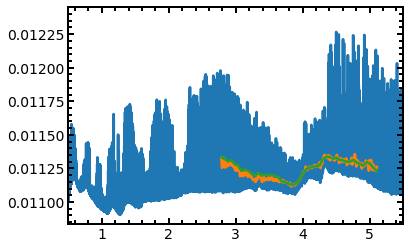

Regenerating spectra 701
Regenerating spectra 702
Regenerating spectra 703
Regenerating spectra 704
Regenerating spectra 705
Regenerating spectra 706
Regenerating spectra 707
Regenerating spectra 708
Regenerating spectra 709
Regenerating spectra 710
Regenerating spectra 711
Regenerating spectra 712
Regenerating spectra 713
Regenerating spectra 714
Regenerating spectra 715
Regenerating spectra 716
Regenerating spectra 717
Regenerating spectra 718
Regenerating spectra 719
Regenerating spectra 720
Regenerating spectra 721
Regenerating spectra 722
Regenerating spectra 723
Regenerating spectra 724
Regenerating spectra 725
Regenerating spectra 726
Regenerating spectra 727
Regenerating spectra 728
Regenerating spectra 729
Regenerating spectra 730
Regenerating spectra 731
Regenerating spectra 732
Regenerating spectra 733
Regenerating spectra 734
Regenerating spectra 735
Regenerating spectra 736
Regenerating spectra 737
Regenerating spectra 738
Regenerating spectra 739
Regenerating spectra 740


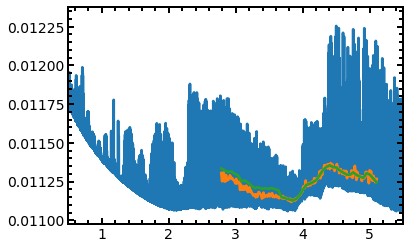

Regenerating spectra 751
Regenerating spectra 752
Regenerating spectra 753
Regenerating spectra 754
Regenerating spectra 755
Regenerating spectra 756
Regenerating spectra 757
Regenerating spectra 758
Regenerating spectra 759
Regenerating spectra 760
Regenerating spectra 761
Regenerating spectra 762
Regenerating spectra 763
Regenerating spectra 764
Regenerating spectra 765
Regenerating spectra 766
Regenerating spectra 767
Regenerating spectra 768
Regenerating spectra 769
Regenerating spectra 770
Regenerating spectra 771
Regenerating spectra 772
Regenerating spectra 773
Regenerating spectra 774
Regenerating spectra 775
Regenerating spectra 776
Regenerating spectra 777
Regenerating spectra 778
Regenerating spectra 779
Regenerating spectra 780
Regenerating spectra 781
Regenerating spectra 782
Regenerating spectra 783
Regenerating spectra 784
Regenerating spectra 785
Regenerating spectra 786
Regenerating spectra 787
Regenerating spectra 788
Regenerating spectra 789
Regenerating spectra 790


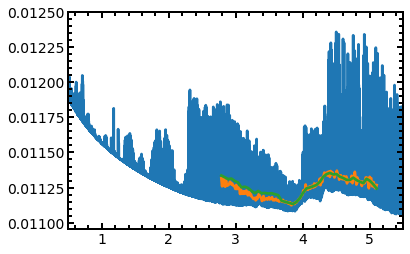

Regenerating spectra 801
Regenerating spectra 802
Regenerating spectra 803
Regenerating spectra 804
Regenerating spectra 805
Regenerating spectra 806
Regenerating spectra 807
Regenerating spectra 808
Regenerating spectra 809
Regenerating spectra 810
Regenerating spectra 811
Regenerating spectra 812
Regenerating spectra 813
Regenerating spectra 814
Regenerating spectra 815
Regenerating spectra 816
Regenerating spectra 817
Regenerating spectra 818
Regenerating spectra 819
Regenerating spectra 820
Regenerating spectra 821
Regenerating spectra 822
Regenerating spectra 823
Regenerating spectra 824
Regenerating spectra 825
Regenerating spectra 826
Regenerating spectra 827
Regenerating spectra 828
Regenerating spectra 829
Regenerating spectra 830
Regenerating spectra 831
Regenerating spectra 832
Regenerating spectra 833
Regenerating spectra 834
Regenerating spectra 835
Regenerating spectra 836
Regenerating spectra 837
Regenerating spectra 838
Regenerating spectra 839
Regenerating spectra 840


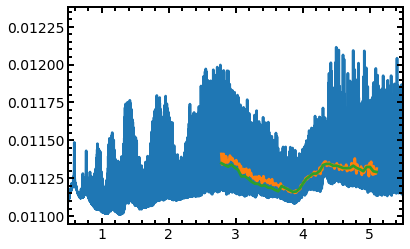

Regenerating spectra 851
Regenerating spectra 852
Regenerating spectra 853
Regenerating spectra 854
Regenerating spectra 855
Regenerating spectra 856
Regenerating spectra 857
Regenerating spectra 858
Regenerating spectra 859
Regenerating spectra 860
Regenerating spectra 861
Regenerating spectra 862
Regenerating spectra 863
Regenerating spectra 864
Regenerating spectra 865
Regenerating spectra 866
Regenerating spectra 867
Regenerating spectra 868
Regenerating spectra 869
Regenerating spectra 870
Regenerating spectra 871
Regenerating spectra 872
Regenerating spectra 873
Regenerating spectra 874
Regenerating spectra 875
Regenerating spectra 876
Regenerating spectra 877
Regenerating spectra 878
Regenerating spectra 879
Regenerating spectra 880
Regenerating spectra 881
Regenerating spectra 882
Regenerating spectra 883
Regenerating spectra 884
Regenerating spectra 885
Regenerating spectra 886
Regenerating spectra 887
Regenerating spectra 888
Regenerating spectra 889
Regenerating spectra 890


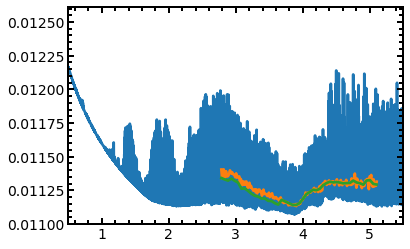

Regenerating spectra 901
Regenerating spectra 902
Regenerating spectra 903
Regenerating spectra 904
Regenerating spectra 905
Regenerating spectra 906
Regenerating spectra 907
Regenerating spectra 908
Regenerating spectra 909
Regenerating spectra 910
Regenerating spectra 911
Regenerating spectra 912
Regenerating spectra 913
Regenerating spectra 914
Regenerating spectra 915
Regenerating spectra 916
Regenerating spectra 917
Regenerating spectra 918
Regenerating spectra 919
Regenerating spectra 920
Regenerating spectra 921
Regenerating spectra 922
Regenerating spectra 923
Regenerating spectra 924
Regenerating spectra 925
Regenerating spectra 926
Regenerating spectra 927
Regenerating spectra 928
Regenerating spectra 929
Regenerating spectra 930
Regenerating spectra 931
Regenerating spectra 932
Regenerating spectra 933
Regenerating spectra 934
Regenerating spectra 935
Regenerating spectra 936
Regenerating spectra 937
Regenerating spectra 938
Regenerating spectra 939
Regenerating spectra 940


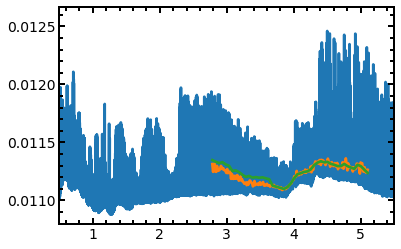

Regenerating spectra 951
Regenerating spectra 952
Regenerating spectra 953
Regenerating spectra 954
Regenerating spectra 955
Regenerating spectra 956
Regenerating spectra 957
Regenerating spectra 958
Regenerating spectra 959
Regenerating spectra 960
Regenerating spectra 961
Regenerating spectra 962
Regenerating spectra 963
Regenerating spectra 964
Regenerating spectra 965
Regenerating spectra 966
Regenerating spectra 967
Regenerating spectra 968
Regenerating spectra 969
Regenerating spectra 970
Regenerating spectra 971
Regenerating spectra 972
Regenerating spectra 973
Regenerating spectra 974
Regenerating spectra 975
Regenerating spectra 976
Regenerating spectra 977
Regenerating spectra 978
Regenerating spectra 979
Regenerating spectra 980
Regenerating spectra 981
Regenerating spectra 982
Regenerating spectra 983
Regenerating spectra 984
Regenerating spectra 985
Regenerating spectra 986
Regenerating spectra 987
Regenerating spectra 988
Regenerating spectra 989
Regenerating spectra 990


In [46]:
spectout = {}
numsamp = min(1000,len(out['equal_samples'][:,0]))
#wavelengths_list,depths_list,info_dict_list,binwv_list,bintd_list = [],[],[],[],[]
depths_list,bintd_list = [],[]
for i in range(numsamp):
    print('Regenerating spectra',i)
    params = out['equal_samples'][i,:]
    datawv = out['transit_wavelengths']
    #vmrs=[]
    #for j in range(len(species)-1):
    #    vmrs.append(10.**params[j])
    #vmrs.append(1.-np.sum(vmrs))
    Rs = params[0]
    Mp = params[1]
    Rp = params[2]
    T = params[3]
    logZ = params[6]
    CO_ratio = params[9]
    wavelengths, depths, info_dict = calculator.compute_depths(Rs, Mp, Rp, T, logZ=logZ, CO_ratio=CO_ratio, 
                                                               #gases=species,vmrs=vmrs, 
                                                               scattering_factor=10.**params[4],
                                                               scattering_slope=params[5],
                                                               cloudtop_pressure=10.**params[7],
                                                               T_star=6490.,full_output=True)
    binwv = np.linspace(np.min(datawv),np.max(datawv),num=200)    
    bintd = spectres(binwv, wavelengths, depths)

    if i%50 == 0:
        plt.plot(wavelengths*1e6,depths)
        plt.plot(binwv*1e6,bintd)
        plt.plot(out['transit_wavelengths']*1e6,out['random_transit_depths'][i])
        plt.xlim([0.5,5.5])
        plt.show()        

    #wavelengths_list.append(wavelengths)
    depths_list.append(depths)
    #info_dict_list.append(info_dict)
    #binwv_list.append(binwv)
    bintd_list.append(bintd)

spectout['wavelengths'] = wavelengths
spectout['depths'] = depths_list
#spectout['info_dict'] = info_dict_list
spectout['binwv'] = binwv
spectout['bintd'] = bintd_list

f = open('toi2031b_eureka50nm_200PointRandomModelSpectra.pkl','wb')
pickle.dump(spectout,f)
f.close()

In [48]:
fname = 'toi2031b_eureka50nm_200PointRandomModelSpectra.pkl'
with open(fname,'rb') as f:
    spec = pickle.load(f)

In [54]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,5), facecolor='w')
ax.errorbar(wv['eureka']['50nm']*1e6,td['eureka']['50nm']*1e2,yerr=tderr['eureka']['50nm']*1e2,
            ls='',color='k',marker='o',zorder=3)
ax.set_xlabel('Wavelength ($\mu$m)')
ax.set_ylabel('Transit Depth (%)')  
#ax.set_ylim([550,1050])
ax.set_ylim([1.1,1.16])


lower_spectrum_1sig = np.percentile(spec['bintd'], 15.865, axis=0)
upper_spectrum_1sig = np.percentile(spec['bintd'], 84.135, axis=0)
lower_spectrum_2sig = np.percentile(spec['bintd'], 2.275, axis=0)
upper_spectrum_2sig = np.percentile(spec['bintd'], 97.725, axis=0)
lower_spectrum_3sig = np.percentile(spec['bintd'], 0.135, axis=0)
upper_spectrum_3sig = np.percentile(spec['bintd'], 99.865, axis=0)


ax.fill_between(spec['binwv']*1e6,
                 lower_spectrum_3sig*1e2,
                 upper_spectrum_3sig*1e2,
                 color='xkcd:azure',zorder=0,alpha=0.2)
ax.fill_between(spec['binwv']*1e6,
                 lower_spectrum_2sig*1e2,
                 upper_spectrum_2sig*1e2,
                 color='xkcd:azure',zorder=1,alpha=0.5)
ax.fill_between(spec['binwv']*1e6,
                 lower_spectrum_1sig*1e2,
                 upper_spectrum_1sig*1e2,
                 color='xkcd:azure',zorder=2,alpha=1)

plt.savefig('fig_eureka_50nm_retrieval.png', format = 'png')
#plt.savefig('fig_models_toi402.02_final2.pdf', format = 'pdf')
plt.close() 



In [65]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (5,5), facecolor='w')


ct = az.plot_kde(out['equal_samples'][:,6],out['equal_samples'][:,9],
                 hdi_probs=[0.393, 0.865, 0.989],ax=ax,
                 contourf_kwargs={'colors': 'xkcd:azure', 'alpha': 0.3},
                 contour_kwargs={'colors': 'xkcd:azure'})

#ct = az.plot_kde(np.log10(mettot5me/M0),ctoo5me,
#                 hdi_probs=[0.393, 0.865, 0.989],ax=ax2,
#                 contourf_kwargs={'colors': colors[ii], 'alpha': 0.3},
#                 contour_kwargs={'colors': colors[ii]}) 

#ax2.annotate(annotes[ii],xy=(1,0.5),xytext=(-0.7,0.45-ii*0.05),color=colors[ii],horizontalalignment='left') 

ax.axhline(0.59,color='gray',linestyle='--')
ax.axvline(0,color='gray',linestyle='--')
#ax2.axhline(0.59,color='gray',linestyle='--')

#ax1.set_ylim([0,0.65])
#ax1.set_xlim([-1.5,3.5])

#ax1.annotate('Outside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 
#ax2.annotate('Inside 2:1 Mass Prior',xy=(0.5,0.5),xytext=(0.5,1.04),color='k',xycoords='axes fraction',
#             verticalalignment='center',horizontalalignment='center') 

#ax1.annotate('Solar C/O = 0.59 (Asplund et al. 2021)',xy=(0,0.5),xytext=(1,0.56),color='gray',
#             horizontalalignment='center') 
#ax2.annotate('Solar C/O = 0.59 (Asplund et al. 2021)',xy=(0,0.5),xytext=(1,0.56),color='gray',
#             horizontalalignment='center') 

ax.set_ylabel('C/O')
ax.set_xlabel('[M/H]')

plt.savefig('fig_metc2oposteriors.png', format = 'png')
plt.close()

Regenerating spectra 0


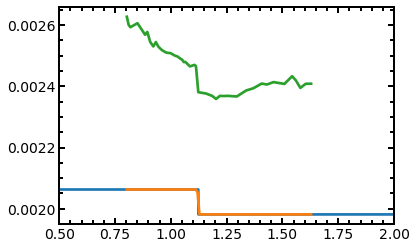

Regenerating spectra 1
Regenerating spectra 2
Regenerating spectra 3
Regenerating spectra 4
Regenerating spectra 5
Regenerating spectra 6
Regenerating spectra 7
Regenerating spectra 8
Regenerating spectra 9
Regenerating spectra 10
Regenerating spectra 11
Regenerating spectra 12
Regenerating spectra 13
Regenerating spectra 14
Regenerating spectra 15
Regenerating spectra 16
Regenerating spectra 17
Regenerating spectra 18
Regenerating spectra 19
Regenerating spectra 20
Regenerating spectra 21
Regenerating spectra 22
Regenerating spectra 23
Regenerating spectra 24
Regenerating spectra 25
Regenerating spectra 26
Regenerating spectra 27
Regenerating spectra 28
Regenerating spectra 29
Regenerating spectra 30
Regenerating spectra 31
Regenerating spectra 32
Regenerating spectra 33
Regenerating spectra 34
Regenerating spectra 35
Regenerating spectra 36
Regenerating spectra 37
Regenerating spectra 38
Regenerating spectra 39
Regenerating spectra 40
Regenerating spectra 41
Regenerating spectra 42
R

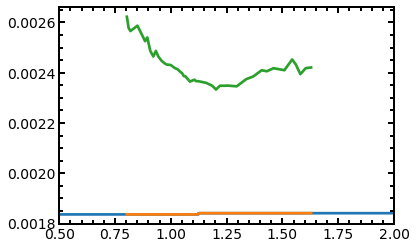

Regenerating spectra 51
Regenerating spectra 52
Regenerating spectra 53
Regenerating spectra 54
Regenerating spectra 55
Regenerating spectra 56
Regenerating spectra 57
Regenerating spectra 58
Regenerating spectra 59
Regenerating spectra 60
Regenerating spectra 61
Regenerating spectra 62
Regenerating spectra 63
Regenerating spectra 64
Regenerating spectra 65
Regenerating spectra 66
Regenerating spectra 67
Regenerating spectra 68
Regenerating spectra 69
Regenerating spectra 70
Regenerating spectra 71
Regenerating spectra 72
Regenerating spectra 73
Regenerating spectra 74
Regenerating spectra 75
Regenerating spectra 76
Regenerating spectra 77
Regenerating spectra 78
Regenerating spectra 79
Regenerating spectra 80
Regenerating spectra 81
Regenerating spectra 82
Regenerating spectra 83
Regenerating spectra 84
Regenerating spectra 85
Regenerating spectra 86
Regenerating spectra 87
Regenerating spectra 88
Regenerating spectra 89
Regenerating spectra 90
Regenerating spectra 91
Regenerating spe

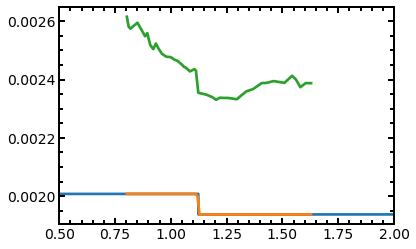

Regenerating spectra 101
Regenerating spectra 102
Regenerating spectra 103
Regenerating spectra 104
Regenerating spectra 105
Regenerating spectra 106
Regenerating spectra 107
Regenerating spectra 108
Regenerating spectra 109
Regenerating spectra 110
Regenerating spectra 111
Regenerating spectra 112
Regenerating spectra 113
Regenerating spectra 114
Regenerating spectra 115
Regenerating spectra 116
Regenerating spectra 117
Regenerating spectra 118
Regenerating spectra 119
Regenerating spectra 120
Regenerating spectra 121
Regenerating spectra 122
Regenerating spectra 123
Regenerating spectra 124
Regenerating spectra 125
Regenerating spectra 126
Regenerating spectra 127
Regenerating spectra 128
Regenerating spectra 129
Regenerating spectra 130
Regenerating spectra 131
Regenerating spectra 132
Regenerating spectra 133
Regenerating spectra 134
Regenerating spectra 135
Regenerating spectra 136
Regenerating spectra 137
Regenerating spectra 138
Regenerating spectra 139
Regenerating spectra 140


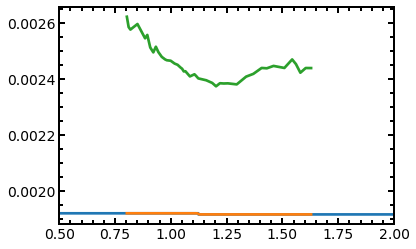

Regenerating spectra 151
Regenerating spectra 152
Regenerating spectra 153
Regenerating spectra 154
Regenerating spectra 155
Regenerating spectra 156
Regenerating spectra 157
Regenerating spectra 158
Regenerating spectra 159
Regenerating spectra 160
Regenerating spectra 161
Regenerating spectra 162
Regenerating spectra 163
Regenerating spectra 164
Regenerating spectra 165
Regenerating spectra 166
Regenerating spectra 167
Regenerating spectra 168
Regenerating spectra 169
Regenerating spectra 170
Regenerating spectra 171
Regenerating spectra 172
Regenerating spectra 173
Regenerating spectra 174
Regenerating spectra 175
Regenerating spectra 176
Regenerating spectra 177
Regenerating spectra 178
Regenerating spectra 179
Regenerating spectra 180
Regenerating spectra 181
Regenerating spectra 182
Regenerating spectra 183
Regenerating spectra 184
Regenerating spectra 185
Regenerating spectra 186
Regenerating spectra 187
Regenerating spectra 188
Regenerating spectra 189
Regenerating spectra 190


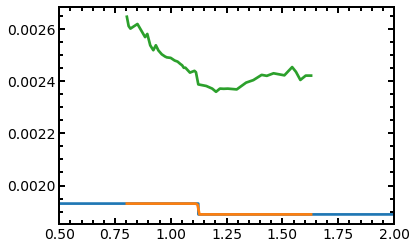

Regenerating spectra 201
Regenerating spectra 202
Regenerating spectra 203
Regenerating spectra 204
Regenerating spectra 205
Regenerating spectra 206
Regenerating spectra 207
Regenerating spectra 208
Regenerating spectra 209
Regenerating spectra 210
Regenerating spectra 211
Regenerating spectra 212
Regenerating spectra 213
Regenerating spectra 214
Regenerating spectra 215
Regenerating spectra 216
Regenerating spectra 217
Regenerating spectra 218
Regenerating spectra 219
Regenerating spectra 220
Regenerating spectra 221
Regenerating spectra 222
Regenerating spectra 223
Regenerating spectra 224
Regenerating spectra 225
Regenerating spectra 226
Regenerating spectra 227
Regenerating spectra 228
Regenerating spectra 229
Regenerating spectra 230
Regenerating spectra 231
Regenerating spectra 232
Regenerating spectra 233
Regenerating spectra 234
Regenerating spectra 235
Regenerating spectra 236
Regenerating spectra 237
Regenerating spectra 238
Regenerating spectra 239
Regenerating spectra 240


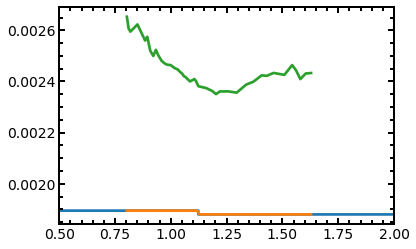

Regenerating spectra 251
Regenerating spectra 252
Regenerating spectra 253
Regenerating spectra 254
Regenerating spectra 255
Regenerating spectra 256
Regenerating spectra 257
Regenerating spectra 258
Regenerating spectra 259
Regenerating spectra 260
Regenerating spectra 261
Regenerating spectra 262


KeyboardInterrupt: 

In [88]:
spectouttls = {}
numsamp = min(1000,len(outtls['equal_samples'][:,0]))
#wavelengths_list,depths_list,info_dict_list,binwv_list,bintd_list = [],[],[],[],[]
depths_list,bintd_list = [],[]
for i in range(numsamp):
    print('Regenerating spectra',i)
    params = outtls['equal_samples'][i,:]
    datawv = outtls['transit_wavelengths']
    #vmrs=[]
    #for j in range(len(species)-1):
    #    vmrs.append(10.**params[j])
    #vmrs.append(1.-np.sum(vmrs))
    Rs = 0.82*R_sun
    Mp = 10.*M_earth
    Rp = params[2]
    T = 600.0
    logZ = -1.
    CO_ratio = 0.59
    wavelengths, depths, info_dict = calculator.compute_depths(Rs, Mp, Rp, T, logZ=logZ, CO_ratio=CO_ratio, 
                                                               #gases=species,vmrs=vmrs, 
                                                               scattering_factor=1.,
                                                               scattering_slope=4.,
                                                               cloudtop_pressure=10.**-3.999,
                                                               T_star=params[0],#T_spot=params[1],
                                                               #spot_cov_frac=params[3],
                                                               full_output=True)
        
    depths[0:len(wavelengths[wavelengths<datawv[n102-1]])] += params[5]
    
    binwv = np.linspace(np.min(datawv),np.max(datawv),num=100)    
    bintd = spectres(binwv, wavelengths, depths)

    if i%50 == 0:
        plt.plot(wavelengths*1e6,depths)
        plt.plot(binwv*1e6,bintd)
        plt.plot(outtls['transit_wavelengths']*1e6,outtls['random_transit_depths'][i])
        plt.xlim([0.5,2.0])
        plt.show()        

    #wavelengths_list.append(wavelengths)
    depths_list.append(depths)
    #info_dict_list.append(info_dict)
    #binwv_list.append(binwv)
    bintd_list.append(bintd)

spectouttls['wavelengths'] = wavelengths
spectouttls['depths'] = depths_list
#spectouttls['info_dict'] = info_dict_list
spectouttls['binwv'] = binwv
spectouttls['bintd'] = bintd_list